# 01. Video Input and Pre processing

## convert a phone video

In [1]:
# convert a phone video to constant 30 fps
!ffmpeg -i /kaggle/input/datasets/dinethm/bed-monitor-sample/0000.mp4 -vf fps=30 -c:v libx264 -crf 20 -an output_cfr.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

## 1.1: Logging setup

In [2]:
import logging, sys
from pathlib import Path

LOG_FORMAT = "%(asctime)s | %(levelname)-7s | %(name)s | %(message)s"
DATE_FORMAT = "%H:%M:%S"

def get_logger(name: str = "bedmonitor", level: int = logging.INFO) -> logging.Logger:
    logger = logging.getLogger(name)
    logger.setLevel(level)
    logger.propagate = False  # stops duplicate lines
    if not logger.handlers:
        handler = logging.StreamHandler(sys.stdout)
        handler.setFormatter(logging.Formatter(LOG_FORMAT, DATE_FORMAT))
        logger.addHandler(handler)
    return logger

def add_file_handler(logger: logging.Logger, log_path) -> None:
    log_path = Path(log_path).resolve()
    log_path.parent.mkdir(parents=True, exist_ok=True)
    for h in logger.handlers:
        if isinstance(h, logging.FileHandler) and Path(h.baseFilename) == log_path:
            return
    fh = logging.FileHandler(log_path, encoding="utf-8")
    fh.setFormatter(logging.Formatter(LOG_FORMAT, DATE_FORMAT))
    logger.addHandler(fh)

log = get_logger()                              # main logger
video_log = logging.getLogger("bedmonitor.video")   # child logger for video code

## 1.2: Environment check

In [3]:
import platform, os

IN_KAGGLE = os.path.exists("/kaggle/working")
IN_COLAB = "google.colab" in sys.modules

log.info("Python %s", platform.python_version())
log.info("Platform: %s", "Kaggle" if IN_KAGGLE else "Colab" if IN_COLAB else "Local")

try:
    import torch
    log.info("Torch %s", torch.__version__)
    if torch.cuda.is_available():
        log.info("GPU: %s", torch.cuda.get_device_name(0))
    else:
        log.warning("No GPU found")
except ImportError:
    log.warning("Torch is not installed")

05:29:00 | INFO    | bedmonitor | Python 3.12.13
05:29:00 | INFO    | bedmonitor | Platform: Kaggle
05:29:08 | INFO    | bedmonitor | Torch 2.10.0+cu128
05:29:08 | INFO    | bedmonitor | GPU: Tesla T4


## 1.3: Install packages

In [4]:
!pip install -q -U ultralytics opencv-python-headless pandas pyarrow pyyaml lap "onnxruntime-gpu<1.27"
!pip freeze > /tmp/requirements_run.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 MB 33.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 99.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 39.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 7.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 4.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=

## 1.4: Paths and config

In [5]:
from dataclasses import dataclass, asdict
import json

if IN_KAGGLE:
    BASE_DIR = Path("/kaggle/working")
elif IN_COLAB:
    BASE_DIR = Path("/content")
else:
    BASE_DIR = Path.cwd()

@dataclass
class Config:
    video_path: str = ""
    output_dir: str = str(BASE_DIR / "outputs")

    # Frame sampling
    sample_fps: float = 4.0     # frames per second to analyze
    max_side: int = 1280        # resize so the longest side is at most this

    # Models
    pose_model: str = "yolo26m-pose.pt"
    tracker: str = "botsort.yaml"

    def save(self, path: Path):
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2))
        log.info("Config saved to %s", path)

cfg = Config(video_path="/kaggle/input/datasets/dinethm/bed-monitor-sample/0000.mp4")
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
add_file_handler(log, Path(cfg.output_dir) / "run.log")

log.info("Output folder: %s", cfg.output_dir)
log.info("Config: %s", asdict(cfg))

05:29:43 | INFO    | bedmonitor | Output folder: /kaggle/working/outputs
05:29:43 | INFO    | bedmonitor | Config: {'video_path': '/kaggle/input/datasets/dinethm/bed-monitor-sample/0000.mp4', 'output_dir': '/kaggle/working/outputs', 'sample_fps': 4.0, 'max_side': 1280, 'pose_model': 'yolo26m-pose.pt', 'tracker': 'botsort.yaml'}


## 1.5: Time helpers

In [6]:
def fmt_time(sec: float) -> str:
    """Seconds to 'HH:MM:SS'"""
    sec = int(round(sec))
    h, rem = divmod(sec, 3600)
    m, s = divmod(rem, 60)
    return f"{h:02d}:{m:02d}:{s:02d}"

def fmt_duration(sec: float) -> str:
    """Seconds to '11m 42s' style"""
    sec = int(round(sec))
    m, s = divmod(sec, 60)
    return f"{m}m {s:02d}s" if m else f"{s}s"

## 1.6: Read video metadata

In [7]:
import cv2

@dataclass
class VideoInfo:
    path: str
    fps: float
    frame_count: int
    width: int
    height: int
    duration_sec: float

def probe_video(path: str) -> VideoInfo:
    """Read basic video info. Fails early if the file cannot be used."""
    video_log.info("Opening video: %s", path)

    if not Path(path).exists():
        video_log.error("File not found: %s", path)
        raise FileNotFoundError(f"Video not found: {path}")

    cap = cv2.VideoCapture(path)
    if not cap.isOpened():
        video_log.error("OpenCV cannot open the file: %s", path)
        raise IOError(f"OpenCV cannot open: {path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    if fps is None or fps <= 0 or fps > 240:
        video_log.error("Bad fps value: %s. Convert the video with ffmpeg.", fps)
        raise ValueError(f"Bad fps value ({fps}).")

    if frame_count <= 0:
        video_log.error("Bad frame count: %s. Convert the video with ffmpeg.", frame_count)
        raise ValueError(f"Bad frame count ({frame_count}).")

    info = VideoInfo(
        path=path,
        fps=fps,
        frame_count=frame_count,
        width=width,
        height=height,
        duration_sec=frame_count / fps,
    )
    video_log.info(
        "Video: %dx%d, %.2f fps, %d frames, duration %s",
        width, height, fps, frame_count, fmt_time(info.duration_sec),
    )
    return info

info = probe_video(cfg.video_path)

05:29:44 | INFO    | bedmonitor.video | Opening video: /kaggle/input/datasets/dinethm/bed-monitor-sample/0000.mp4
05:29:44 | INFO    | bedmonitor.video | Video: 1280x720, 29.82 fps, 356 frames, duration 00:00:12


## 1.7: Frame sampler

In [8]:
import time
import numpy as np
from typing import Iterator

@dataclass
class SampledFrame:
    sample_idx: int      # 0,1,2,... in the sampled sequence
    frame_idx: int       # index in the original video
    t_sec: float         # timestamp in seconds
    image: np.ndarray    # BGR image (OpenCV format)

def resize_max_side(img: np.ndarray, max_side: int) -> np.ndarray:
    h, w = img.shape[:2]
    scale = max_side / max(h, w)
    if scale >= 1.0:
        return img
    return cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_AREA)

def sample_frames(
    info: VideoInfo,
    sample_fps: float,
    max_side: int = 1280,
    start_sec: float = 0.0,
    end_sec: float | None = None,
    log_every_sec: float = 60.0,
) -> Iterator[SampledFrame]:
    """
    Read the video in order and keep frames at `sample_fps`.
    Timestamps come from frame_index / native_fps, so the video must be constant fps.
    `grab()` skips decoding work for frames we do not keep.
    Logs progress every `log_every_sec` seconds of video.
    """
    if sample_fps <= 0:
        video_log.error("sample_fps must be > 0 (got %s)", sample_fps)
        raise ValueError("sample_fps must be > 0")

    if sample_fps > info.fps:
        video_log.warning(
            "sample_fps %.2f is above video fps %.2f. Using %.2f.",
            sample_fps, info.fps, info.fps,
        )
        sample_fps = info.fps

    end_sec = info.duration_sec if end_sec is None else min(end_sec, info.duration_sec)
    if start_sec >= end_sec:
        video_log.error("start_sec (%.2f) must be before end_sec (%.2f)", start_sec, end_sec)
        raise ValueError("start_sec must be before end_sec")

    video_log.info(
        "Sampling %s -> %s at %.2f fps (max_side=%d)",
        fmt_time(start_sec), fmt_time(end_sec), sample_fps, max_side,
    )

    cap = cv2.VideoCapture(info.path)
    start_frame = int(round(start_sec * info.fps))
    if start_frame > 0:
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
        video_log.debug("Jumped to frame %d", start_frame)

    step = 1.0 / sample_fps
    next_t = start_sec
    frame_idx = start_frame
    sample_idx = 0
    last_t = None
    t_sec = start_sec
    next_log_t = start_sec + log_every_sec
    grab_failed = False
    decode_failures = 0
    wall_start = time.perf_counter()

    try:
        while True:
            t_sec = frame_idx / info.fps
            if t_sec > end_sec:
                break
            if not cap.grab():
                grab_failed = True
                break

            if t_sec + 1e-6 >= next_t:
                ok, img = cap.retrieve()
                if ok and img is not None:
                    frame = SampledFrame(
                        sample_idx=sample_idx,
                        frame_idx=frame_idx,
                        t_sec=round(t_sec, 3),
                        image=resize_max_side(img, max_side),
                    )
                    sample_idx += 1
                    last_t = t_sec
                    yield frame
                else:
                    decode_failures += 1
                    video_log.warning("Could not decode frame %d (t=%.2fs). Skipped.", frame_idx, t_sec)
                next_t += step

            if t_sec >= next_log_t:
                video_log.info(
                    "Progress: %s / %s (%d samples)",
                    fmt_time(t_sec), fmt_time(end_sec), sample_idx,
                )
                next_log_t += log_every_sec

            frame_idx += 1
    finally:
        cap.release()
        elapsed = time.perf_counter() - wall_start
        video_log.info(
            "Done: %d samples, last t=%.2fs, %.1fs elapsed",
            sample_idx, last_t if last_t is not None else -1, elapsed,
        )
        if decode_failures:
            video_log.warning("%d frames could not be decoded", decode_failures)
        if grab_failed and end_sec - t_sec > 1.0:
            video_log.warning(
                "Video ended early at %.2fs (expected %.2fs). The file may be damaged.",
                t_sec, end_sec,
            )

## 1.8: Quick check

05:29:45 | INFO    | bedmonitor.video | Sampling 00:00:00 -> 00:00:10 at 4.00 fps (max_side=1280)
05:29:46 | INFO    | bedmonitor.video | Done: 40 samples, last t=9.76s, 0.8s elapsed
05:29:46 | INFO    | bedmonitor | Sampled 40 frames from the first 10 s (expected about 41)


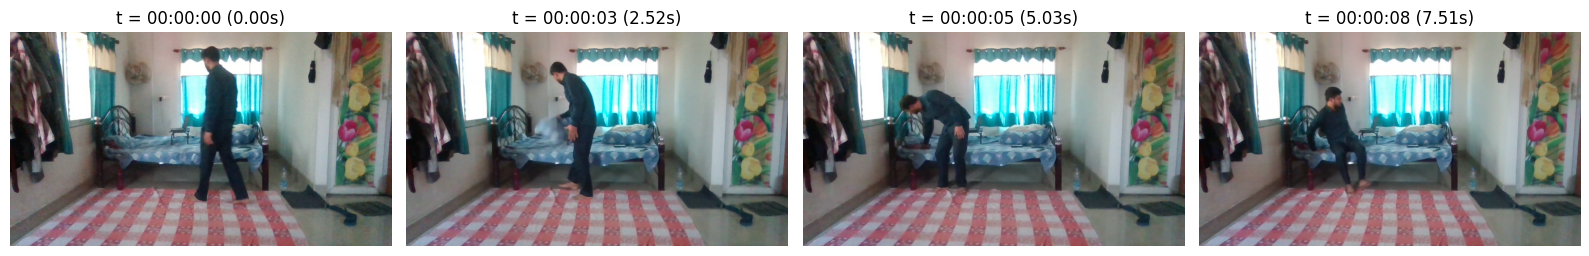

05:29:47 | INFO    | bedmonitor | Config saved to /kaggle/working/outputs/config.json


In [9]:
import matplotlib.pyplot as plt

frames = list(sample_frames(info, cfg.sample_fps, cfg.max_side, start_sec=0, end_sec=10))

expected = int(10 * min(cfg.sample_fps, info.fps)) + 1
log.info("Sampled %d frames from the first 10 s (expected about %d)", len(frames), expected)
if abs(len(frames) - expected) > 1:
    log.warning("Frame count differs from expected. Check the video fps.")

show = frames[:: max(1, len(frames) // 4)][:4]
fig, axes = plt.subplots(1, len(show), figsize=(4 * len(show), 3))
axes = np.atleast_1d(axes)
for ax, f in zip(axes, show):
    ax.imshow(cv2.cvtColor(f.image, cv2.COLOR_BGR2RGB))
    ax.set_title(f"t = {fmt_time(f.t_sec)} ({f.t_sec:.2f}s)")
    ax.axis("off")
plt.tight_layout()
plt.show()

cfg.save(Path(cfg.output_dir) / "config.json")

# 2. Scene Steup

## 2.1: Scene config

In [10]:
from dataclasses import dataclass, asdict
from pathlib import Path
import json
import logging
import numpy as np
import cv2

scene_log = logging.getLogger("bedmonitor.scene")

@dataclass
class SceneConfig:
    detect_model: str = "yolo26m.pt"   # for furnitures
    setup_window_sec: float = 60.0     # look first 60s of video
    setup_fps: float = 0.5             # 1 frame every 2 s -> about 30 frames
    det_conf: float = 0.25
    det_imgsz: int = 640
    det_batch: int = 8
    cluster_iou: float = 0.5           # boxes with IoU above this are the same object
    min_bed_presence: float = 0.3      # bed must appear in >= 30% of setup frames
    min_furniture_presence: float = 0.3
    bed_edge_margin_ratio: float = 0.08  # edge band = 8% of bed width
    exit_border_ratio: float = 0.05      # frame border band = 5% of the short side
    dark_threshold: float = 50.0         # mean gray level (0-255) below this for poor lighting
    ref_width: int = 320                 # width of the stored reference frame
    camera_shift_px: float = 8.0         # shift (in reference pixels) that counts as camera movement
    # Manual overrides, in pixels of the SAMPLED frame (after max_side resize)
    bed_polygon: list | None = None      # e.g. [[120, 300], [700, 300], [700, 620], [120, 620]]
    door_polygon: list | None = None

    def save(self, path: Path):
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2))
        scene_log.info("Scene config saved to %s", path)

scfg = SceneConfig()

## 2.2: Geometry helpers

In [11]:
# intersection over union(IOU) measures how much two boxes overlap, from 0 (none) to 1 (identical)
def box_area(b) -> float:
    return max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])

def box_iou(a, b) -> float:
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    union = box_area(a) + box_area(b) - inter
    return inter / union if union > 0 else 0.0

def box_to_polygon(b) -> list:
    x1, y1, x2, y2 = [int(round(v)) for v in b]
    return [[x1, y1], [x2, y1], [x2, y2], [x1, y2]]

def polygon_bbox(poly) -> list:
    pts = np.array(poly, dtype=np.float32)
    return [float(pts[:, 0].min()), float(pts[:, 1].min()), float(pts[:, 0].max()), float(pts[:, 1].max())]

def signed_distance(pt, poly) -> float:
    """Pixels from point to polygon edge. Positive = inside, negative = outside."""
    contour = np.array(poly, dtype=np.float32).reshape(-1, 1, 2)
    return float(cv2.pointPolygonTest(contour, (float(pt[0]), float(pt[1])), True))

def in_zone(pt, poly, margin: float = 0.0) -> bool:
    """True if the point is inside the polygon, or within `margin` pixels outside it."""
    return signed_distance(pt, poly) >= -margin

def cluster_boxes(dets: list, iou_thr: float) -> list:
    """
    Group detections of the same static object across frames.
    Each detection: {"box": (x1,y1,x2,y2), "conf": float, "frame": int}.
    Returns clusters with the median box, the number of frames it appeared in, and mean confidence.
    """
    clusters = []
    for d in sorted(dets, key=lambda d: -d["conf"]):
        for c in clusters:
            if box_iou(d["box"], c["median"]) >= iou_thr:
                c["boxes"].append(d["box"])
                c["confs"].append(d["conf"])
                c["frames"].add(d["frame"])
                c["median"] = tuple(np.median(np.array(c["boxes"]), axis=0))
                break
        else:
            clusters.append({"boxes": [d["box"]], "confs": [d["conf"]],
                             "frames": {d["frame"]}, "median": d["box"]})
    return [
        {"box": [float(v) for v in c["median"]], "hits": len(c["frames"]),
         "mean_conf": float(np.mean(c["confs"]))}
        for c in clusters
    ]

## 2.3: Furniture detection

In [12]:
# If a person or blanket distorts the bed box in a few frames, the median ignores those outliers.

FURNITURE_CLASSES = {56: "chair", 57: "couch", 59: "bed", 62: "tv"}  # COCO class ids

def detect_furniture(model, frames: list, scfg: SceneConfig) -> dict:
    """Run the detector on the setup frames. Returns detections grouped by class name."""
    dets = {name: [] for name in FURNITURE_CLASSES.values()}
    scene_log.info("Detecting furniture in %d frames with %s", len(frames), scfg.detect_model)

    for i in range(0, len(frames), scfg.det_batch):
        chunk = frames[i:i + scfg.det_batch]
        results = model.predict(
            [f.image for f in chunk],
            classes=list(FURNITURE_CLASSES),
            conf=scfg.det_conf,
            imgsz=scfg.det_imgsz,
            verbose=True,
        )
        for f, r in zip(chunk, results):
            boxes = r.boxes.xyxy.cpu().numpy()
            classes = r.boxes.cls.cpu().numpy().astype(int)
            confs = r.boxes.conf.cpu().numpy()
            for b, c, s in zip(boxes, classes, confs):
                dets[FURNITURE_CLASSES[int(c)]].append(
                    {"box": tuple(float(v) for v in b), "conf": float(s), "frame": f.sample_idx}
                )

    for name, items in dets.items():
        scene_log.info("  %-5s: %d detections", name, len(items))
    return dets

## 2.4: Bed and furniture selection

In [13]:
def select_bed_zone(bed_dets: list, n_frames: int, scfg: SceneConfig) -> dict | None:
    """Pick the bed seen in the most frames. Returns None if no bed is reliable enough."""
    if not bed_dets:
        scene_log.warning("No bed detected in any setup frame")
        return None

    clusters = cluster_boxes(bed_dets, scfg.cluster_iou)
    clusters.sort(key=lambda c: (c["hits"], box_area(c["box"])), reverse=True)
    best = clusters[0]
    presence = best["hits"] / n_frames

    scene_log.info(
        "Bed candidates: %d. Best: seen in %d/%d frames (%.0f%%), mean conf %.2f",
        len(clusters), best["hits"], n_frames, presence * 100, best["mean_conf"],
    )
    if len(clusters) > 1 and clusters[1]["hits"] >= 0.7 * best["hits"]:
        scene_log.warning("A second bed-like object is also often seen. Check the overview image.")

    if presence < scfg.min_bed_presence:
        scene_log.warning(
            "Best bed seen in only %.0f%% of frames (need %.0f%%). Not reliable.",
            presence * 100, scfg.min_bed_presence * 100,
        )
        return None

    return {
        "polygon": box_to_polygon(best["box"]),
        "source": "auto",
        "confidence": best["mean_conf"],
        "presence": presence,
    }

def box_contained_ratio(inner, outer) -> float:
    """Fraction of `inner` box area that lies inside `outer` box."""
    x1, y1 = max(inner[0], outer[0]), max(inner[1], outer[1])
    x2, y2 = min(inner[2], outer[2]), min(inner[3], outer[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area = box_area(inner)
    return inter / area if area > 0 else 0.0

def select_static_objects(dets: list, n_frames: int, scfg: SceneConfig,
                          label: str, bed_box: list | None) -> list:
    """Keep objects seen often enough. Drop ones that sit mostly on the bed."""
    kept = []
    for c in cluster_boxes(dets, scfg.cluster_iou):
        presence = c["hits"] / n_frames
        if presence < scfg.min_furniture_presence:
            scene_log.debug("Dropped %s at %s: seen in only %.0f%% of frames", label, c["box"], presence * 100)
            continue
        if bed_box is not None:
            inside = box_contained_ratio(c["box"], bed_box)
            if box_iou(c["box"], bed_box) > 0.5 or inside > 0.6:
                scene_log.info(
                    "Dropped %s at %s: %.0f%% of it is inside the bed",
                    label, [int(v) for v in c["box"]], inside * 100,
                )
                continue
        kept.append({"label": label, "box": c["box"], "presence": presence, "conf": c["mean_conf"]})
    return kept

## 2.5: Lighting and camera-movement checks

In [14]:
def measure_brightness(img: np.ndarray) -> float:
    """Mean gray level, 0 (black) to 255 (white)."""
    return float(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).mean())

def to_reference(img: np.ndarray, width: int) -> np.ndarray:
    """Small gray copy of a frame, used to check if the camera moved."""
    h, w = img.shape[:2]
    small = cv2.resize(img, (width, int(h * width / w)), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

def check_camera_shift(ref_gray: np.ndarray, img: np.ndarray, scfg: SceneConfig) -> dict:
    """Estimate how far the view moved compared with the reference frame."""
    cur = to_reference(img, ref_gray.shape[1])
    window = cv2.createHanningWindow(cur.shape[::-1], cv2.CV_32F)
    (dx, dy), response = cv2.phaseCorrelate(np.float32(ref_gray), np.float32(cur), window)
    shift = float(np.hypot(dx, dy))
    moved = shift > scfg.camera_shift_px
    if moved:
        scene_log.warning("Camera may have moved: shift %.1f px (dx=%.1f, dy=%.1f)", shift, dx, dy)
    return {"dx": float(dx), "dy": float(dy), "shift": shift, "response": float(response), "moved": moved}

## 2.6: Scene object and builder

In [15]:
@dataclass
class Scene:
    video_path: str
    frame_w: int
    frame_h: int
    bed_polygon: list
    bed_source: str            # "auto" or "manual"
    bed_confidence: float
    bed_presence: float
    bed_edge_margin_px: float  # band around the bed that still counts as "on the bed edge"
    chairs: list               # [{"label", "box", "presence", "conf"}]
    tvs: list
    exit_border_px: int
    door_polygon: list | None
    brightness_mean: float
    brightness_min: float
    poor_lighting: bool
    reference_path: str

    @property
    def bed_box(self) -> list:
        return polygon_bbox(self.bed_polygon)

    def save(self, path: Path):
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2))
        scene_log.info("Scene saved to %s", path)

    @classmethod
    def load(cls, path: Path) -> "Scene":
        return cls(**json.loads(Path(path).read_text()))

def in_exit_zone(pt, scene: Scene) -> bool:
    """True if a point is near the frame border or inside the door zone."""
    x, y = pt
    b = scene.exit_border_px
    near_border = x < b or y < b or x > scene.frame_w - b or y > scene.frame_h - b
    in_door = scene.door_polygon is not None and in_zone(pt, scene.door_polygon)
    return near_border or in_door

def validate_polygon(poly: list, w: int, h: int, name: str) -> list:
    if poly is None or len(poly) < 3:
        raise ValueError(f"{name} needs at least 3 points")
    for x, y in poly:
        if not (0 <= x <= w and 0 <= y <= h):
            scene_log.error("%s point (%s, %s) is outside the frame %dx%d", name, x, y, w, h)
            raise ValueError(f"{name} point outside the frame")
    return [[int(x), int(y)] for x, y in poly]

def build_scene(info, cfg, scfg: SceneConfig, model, out_dir: Path) -> Scene:
    """Find the bed, chairs, TV and exit zones once for this video."""
    end_sec = min(scfg.setup_window_sec, info.duration_sec)
    frames = list(sample_frames(info, scfg.setup_fps, cfg.max_side, 0.0, end_sec))
    if not frames:
        scene_log.error("No setup frames could be read")
        raise RuntimeError("No setup frames")

    h, w = frames[0].image.shape[:2]
    n = len(frames)
    scene_log.info("Scene setup: %d frames from the first %.0f s, frame size %dx%d", n, end_sec, w, h)

    # Lighting
    levels = [measure_brightness(f.image) for f in frames]
    b_mean, b_min = float(np.mean(levels)), float(np.min(levels))
    poor = b_mean < scfg.dark_threshold
    scene_log.info("Brightness: mean %.1f, min %.1f (dark threshold %.0f)", b_mean, b_min, scfg.dark_threshold)
    if poor:
        scene_log.warning("Poor lighting. Expect weaker detections and keypoints.")

    # Furniture
    dets = detect_furniture(model, frames, scfg)

    # Bed zone: manual override first, then auto
    if scfg.bed_polygon is not None:
        bed = {"polygon": validate_polygon(scfg.bed_polygon, w, h, "bed_polygon"),
               "source": "manual", "confidence": 1.0, "presence": 1.0}
        scene_log.info("Using manual bed polygon: %s", bed["polygon"])
    else:
        bed = select_bed_zone(dets["bed"], n, scfg)
        if bed is None:
            scene_log.error(
                "Could not find the bed. Set scfg.bed_polygon by hand "
                "(use show_frame_grid to read pixel positions), then run this cell again."
            )
            raise ValueError("Bed zone not found")
        scene_log.info("Auto bed polygon: %s", bed["polygon"])

    bed_box = polygon_bbox(bed["polygon"])
    edge_margin = scfg.bed_edge_margin_ratio * (bed_box[2] - bed_box[0])

    # Chairs, couches, TVs
    chairs = (select_static_objects(dets["chair"], n, scfg, "chair", bed_box)
              + select_static_objects(dets["couch"], n, scfg, "couch", bed_box))
    tvs = select_static_objects(dets["tv"], n, scfg, "tv", bed_box)
    scene_log.info("Kept %d chair/couch zones and %d TV zones", len(chairs), len(tvs))

    # Exit zones
    door = validate_polygon(scfg.door_polygon, w, h, "door_polygon") if scfg.door_polygon else None
    exit_border = int(scfg.exit_border_ratio * min(w, h))
    scene_log.info("Exit border band: %d px. Door zone: %s", exit_border, "set" if door else "not set")

    # Reference frame for camera-movement checks (use the brightest setup frame)
    ref_frame = frames[int(np.argmax(levels))]
    ref_path = out_dir / "reference_gray.png"
    out_dir.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(ref_path), to_reference(ref_frame.image, scfg.ref_width))
    cv2.imwrite(str(out_dir / "reference_color.jpg"), ref_frame.image)
    scene_log.info("Reference frame saved (t=%.1fs)", ref_frame.t_sec)

    return Scene(
        video_path=info.path, frame_w=w, frame_h=h,
        bed_polygon=bed["polygon"], bed_source=bed["source"],
        bed_confidence=bed["confidence"], bed_presence=bed["presence"],
        bed_edge_margin_px=float(edge_margin),
        chairs=chairs, tvs=tvs,
        exit_border_px=exit_border, door_polygon=door,
        brightness_mean=b_mean, brightness_min=b_min, poor_lighting=poor,
        reference_path=str(ref_path),
    )

## 2.7: Drawing helpers

In [16]:
def draw_scene(img: np.ndarray, scene: Scene) -> np.ndarray:
    """Draw all zones on a copy of the frame."""
    out = img.copy()
    # Exit border band (gray)
    b = scene.exit_border_px
    cv2.rectangle(out, (b, b), (scene.frame_w - b, scene.frame_h - b), (160, 160, 160), 1)
    # Bed (green) and edge band (light green, drawn as a box)
    cv2.polylines(out, [np.array(scene.bed_polygon, np.int32)], True, (0, 200, 0), 2)
    x1, y1, x2, y2 = scene.bed_box
    m = scene.bed_edge_margin_px
    cv2.rectangle(out, (int(x1 - m), int(y1 - m)), (int(x2 + m), int(y2 + m)), (150, 255, 150), 1)
    cv2.putText(out, f"bed ({scene.bed_source})", (int(x1), max(15, int(y1) - 6)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 200, 0), 2)
    # Chairs (blue) and TVs (red)
    for obj, color in [(o, (255, 120, 0)) for o in scene.chairs] + [(o, (0, 0, 255)) for o in scene.tvs]:
        bx = [int(v) for v in obj["box"]]
        cv2.rectangle(out, (bx[0], bx[1]), (bx[2], bx[3]), color, 2)
        cv2.putText(out, obj["label"], (bx[0], max(15, bx[1] - 6)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    # Door (yellow)
    if scene.door_polygon:
        cv2.polylines(out, [np.array(scene.door_polygon, np.int32)], True, (0, 220, 220), 2)
    return out

def show_frame_grid(img: np.ndarray, step: int = 100) -> np.ndarray:
    """Draw a pixel grid on a frame, to read coordinates for a manual polygon."""
    out = img.copy()
    h, w = out.shape[:2]
    for x in range(0, w, step):
        cv2.line(out, (x, 0), (x, h), (0, 255, 255), 1)
        cv2.putText(out, str(x), (x + 2, 14), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
    for y in range(0, h, step):
        cv2.line(out, (0, y), (w, y), (0, 255, 255), 1)
        cv2.putText(out, str(y), (2, y - 2), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
    return out

## 2.8: Run scene setup

In [17]:
from ultralytics import YOLO

video_out = Path(cfg.output_dir) / Path(info.path).stem   # one folder per video
det_model = YOLO(scfg.detect_model)

scene = build_scene(info, cfg, scfg, det_model, video_out)
scene.save(video_out / "scene.json")
scfg.save(video_out / "scene_config.json")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
05:29:54 | INFO    | bedmonitor.video | Sampling 00:00:00 -> 00:00:12 at 0.50 fps (max_side=1280)
05:29:55 | INFO    | bedmonitor.video | Done: 6 samples, last t=10.03s, 0.9s elapsed
05:29:55 | INFO    | bedmonitor.scene | Scene setup: 6 frames from the first 12 s, frame size 1280x720
05:29:55 | INFO    | bedmonitor.scene | Brightness: mean 120.2, min 117.3 (dark threshold 50)
05:29:55 | INFO    | bedmonitor.scene | Detecting furniture in 6 frames with yolo26m.pt

0: 384x640 1 chair, 1 bed, 19.9ms
1: 384x640 1 bed, 19.9ms
2: 384x640 1 bed, 19.9ms
3: 384x640 2 chairs, 1 bed, 19.9ms
4: 384x640 1 bed, 19.9ms
5: 384x640 1 bed, 19.9ms
Speed: 18.3ms preprocess, 19.9ms inference, 18.7ms postprocess per im

## 2.9: Check the result visually

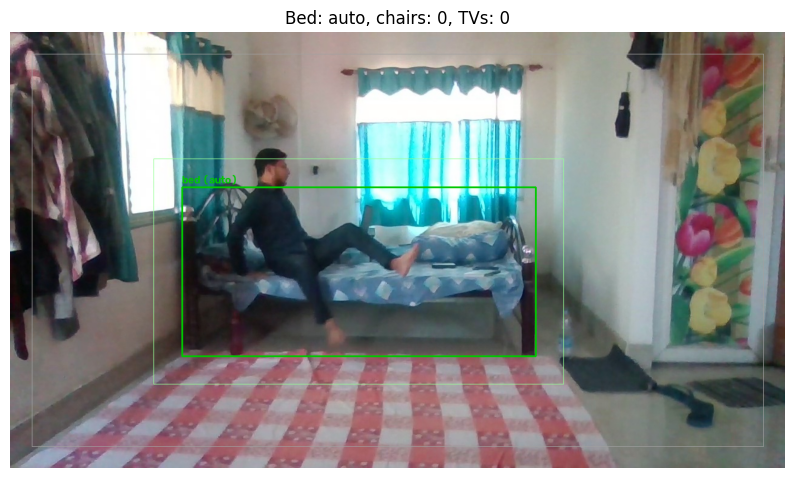

In [18]:
import matplotlib.pyplot as plt

ref_img = cv2.imread(str(video_out / "reference_color.jpg"))
overview = draw_scene(ref_img, scene)
cv2.imwrite(str(video_out / "scene_overview.jpg"), overview)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(overview, cv2.COLOR_BGR2RGB))
plt.title(f"Bed: {scene.bed_source}, chairs: {len(scene.chairs)}, TVs: {len(scene.tvs)}")
plt.axis("off")
plt.show()

## 2.10: Only if the bed is not found or is wrong

05:30:04 | INFO    | bedmonitor.video | Sampling 00:00:00 -> 00:00:05 at 1.00 fps (max_side=1280)
05:30:04 | INFO    | bedmonitor.video | Done: 1 samples, last t=0.00s, 0.0s elapsed


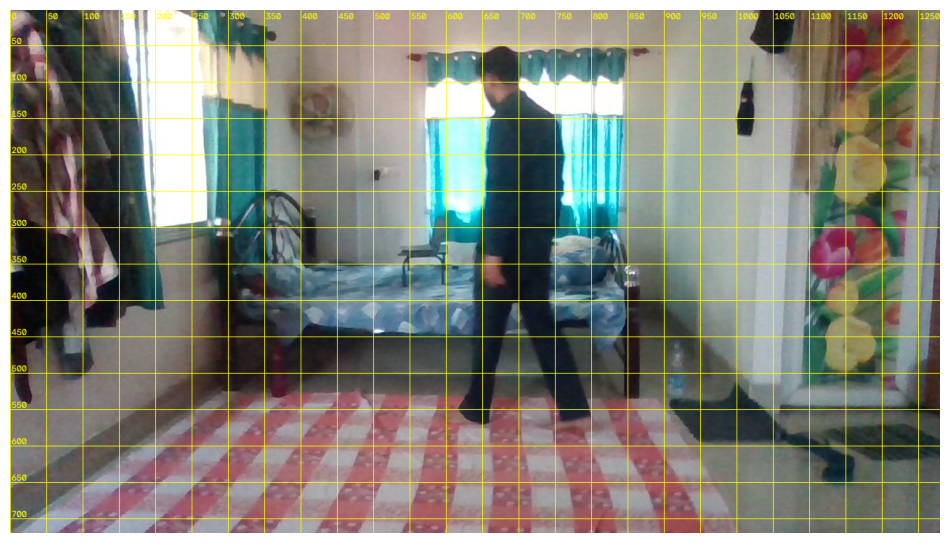

In [19]:
first = next(sample_frames(info, 1.0, cfg.max_side, 0.0, 5.0))
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(show_frame_grid(first.image, step=50), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Example: corners of the mattress, clockwise
# scfg.bed_polygon = [[210, 330], [760, 310], [800, 600], [180, 640]]
# scfg.door_polygon = [[900, 100], [1000, 100], [1000, 450], [900, 450]]

# 03. Perception

## 3.1: Perception config

In [20]:
import logging
from dataclasses import dataclass, asdict, replace
import yaml

perc_log = logging.getLogger("bedmonitor.perception")

@dataclass
class PerceptionConfig:
    pose_conf: float = 0.25          # minimum person confidence
    imgsz: int = 640                 # model input size; try 960 if people look small
    lost_track_sec: float = 10.0     # keep a lost track alive this long (seconds)
    with_reid: bool = True           # use appearance to keep IDs stable
    reid_model: str = "yolo26m-reid.onnx"  # Ultralytics person ReID model
    gmc_method: str = "none"         # camera motion compensation; "none" for a fixed camera
    enhance: str = "auto"            # "auto" | "always" | "never" (contrast boost for dark frames)
    dark_threshold: float = 50.0     # brightness below this triggers the boost in "auto"
    clahe_clip: float = 2.0
    motion_width: int = 320          # width used for motion maps
    motion_pixel_thresh: int = 15    # gray-level change that counts as motion
    camera_check_sec: float = 10.0   # how often to compare with the reference frame

    def save(self, path):
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2))
        perc_log.info("Perception config saved to %s", path)

pcfg = PerceptionConfig()

# Optional: a bigger pose model is more accurate and still fast on a T4
# cfg.pose_model = "yolo26s-pose.pt"

## 3.2: Tracker config builder

In [21]:
# The tracker's track_buffer counts frames, not seconds. At 4 fps, the default of 30 frames is 7.5 seconds. This function converts seconds to frames and writes a custom tracker file.

from ultralytics.utils.checks import check_yaml

def build_tracker_yaml(base: str, pcfg: PerceptionConfig, sample_fps: float,
                       out_path: Path, with_reid: bool) -> Path:
    """Copy an Ultralytics tracker config and apply our settings."""
    base_path = check_yaml(base)
    tcfg = yaml.safe_load(Path(base_path).read_text())

    overrides = {
        "track_buffer": max(1, int(round(pcfg.lost_track_sec * sample_fps))),
        "gmc_method": pcfg.gmc_method,
        "with_reid": with_reid,
        "model": pcfg.reid_model,
    }
    for key, value in overrides.items():
        if key in tcfg:
            tcfg[key] = value
        else:
            perc_log.info("Tracker '%s' has no '%s' setting. Skipped.", tcfg.get("tracker_type"), key)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    out_path.write_text(yaml.safe_dump(tcfg, sort_keys=False))
    perc_log.info(
        "Tracker: %s, track_buffer=%s frames (%.0f s), ReID=%s",
        tcfg.get("tracker_type"), tcfg.get("track_buffer"), pcfg.lost_track_sec, tcfg.get("with_reid", False),
    )
    return out_path

## 3.3: Image helpers

In [22]:
KEYPOINT_NAMES = [
    "nose", "l_eye", "r_eye", "l_ear", "r_ear",
    "l_shoulder", "r_shoulder", "l_elbow", "r_elbow", "l_wrist", "r_wrist",
    "l_hip", "r_hip", "l_knee", "r_knee", "l_ankle", "r_ankle",
]

# CLAHE is a contrast method that brightens dark regions without washing out bright ones. 
# We only use the enhanced image for the model. we measure brightness on the original.
def enhance_contrast(img: np.ndarray, clip: float) -> np.ndarray:
    """Apply CLAHE to the lightness channel only, so colors stay natural."""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    return cv2.cvtColor(cv2.merge([clahe.apply(l), a, b]), cv2.COLOR_LAB2BGR)

def make_zone_mask(polygon: list, frame_w: int, frame_h: int, width: int) -> np.ndarray:
    """Binary mask of a zone, at the small motion-map size."""
    scale = width / frame_w
    height = int(round(frame_h * scale))
    mask = np.zeros((height, width), dtype=np.uint8)
    pts = (np.array(polygon, dtype=np.float32) * scale).astype(np.int32)
    cv2.fillPoly(mask, [pts], 1)
    return mask.astype(bool)

def small_gray(img: np.ndarray, width: int) -> np.ndarray:
    h, w = img.shape[:2]
    small = cv2.resize(img, (width, int(round(h * width / w))), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

# Bed motion is the key signal for the "hidden under blanket" case. The detector may see nobody, while the bed region still moves.
def motion_fraction(prev: np.ndarray, cur: np.ndarray, thresh: int, mask: np.ndarray | None = None) -> float:
    """Fraction of pixels that changed between two small gray frames (inside the mask if given)."""
    changed = cv2.absdiff(prev, cur) > thresh
    if mask is not None:
        total = mask.sum()
        return float((changed & mask).sum() / total) if total else 0.0
    return float(changed.mean())

## 3.4: Read results from one frame

In [23]:
def extract_persons(result, sample_idx: int, t_sec: float, scene: Scene) -> list[dict]:
    """Turn one Ultralytics result into one row per tracked person."""
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return []

    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    ids = boxes.id.cpu().numpy().astype(int) if boxes.id is not None else np.full(len(xyxy), -1)

    kps = result.keypoints
    kp_xy = kps.xy.cpu().numpy() if kps is not None else np.zeros((len(xyxy), 17, 2))
    kp_conf = (kps.conf.cpu().numpy() if kps is not None and kps.conf is not None
               else np.zeros((len(xyxy), 17)))

    rows = []
    for i in range(len(xyxy)):
        x1, y1, x2, y2 = (float(v) for v in xyxy[i])
        center = ((x1 + x2) / 2, (y1 + y2) / 2)
        in_tv = any(in_zone(center, box_to_polygon(tv["box"])) for tv in scene.tvs)
        row = {
            "sample_idx": sample_idx, "t_sec": t_sec, "track_id": int(ids[i]),
            "conf": float(confs[i]), "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "in_tv_zone": in_tv, # in_tv_zone marks people whose box center is on a TV screen. The features layer will ignore them
        }
        for j, name in enumerate(KEYPOINT_NAMES):
            row[f"{name}_x"] = float(kp_xy[i, j, 0])
            row[f"{name}_y"] = float(kp_xy[i, j, 1])
            row[f"{name}_c"] = float(kp_conf[i, j])
        rows.append(row)
    return rows

## 3.5: Cache helpers

In [24]:
def perception_cache_key(info, cfg, pcfg: PerceptionConfig, scene: Scene) -> dict:
    """Everything that changes the perception output. If any value changes, we recompute."""
    import ultralytics
    return {
        "video_path": info.path,
        "video_frames": info.frame_count,
        "sample_fps": cfg.sample_fps,
        "max_side": cfg.max_side,
        "pose_model": cfg.pose_model,
        "tracker": cfg.tracker,
        "perception": asdict(pcfg),
        "bed_polygon": scene.bed_polygon,
        "ultralytics": ultralytics.__version__,
    }

def load_cached_perception(out_dir: Path, key: dict):
    meta_path = out_dir / "perception_meta.json"
    frames_path, persons_path = out_dir / "frames.parquet", out_dir / "persons.parquet"
    if not (meta_path.exists() and frames_path.exists() and persons_path.exists()):
        return None
    meta = json.loads(meta_path.read_text())
    if meta.get("cache_key") != key:
        perc_log.info("Cache found but settings changed. Recomputing.")
        return None
    perc_log.info("Loaded cached perception from %s", out_dir)
    return pd.read_parquet(frames_path), pd.read_parquet(persons_path)

## 3.6: Run perception

In [25]:
import time
import pandas as pd
from ultralytics import YOLO

def run_perception(info, cfg, pcfg: PerceptionConfig, scene: Scene, out_dir: Path,
                   force: bool = False) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Pose + tracking + frame signals for the whole video. Cached to Parquet."""
    key = perception_cache_key(info, cfg, pcfg, scene)
    if not force:
        cached = load_cached_perception(out_dir, key)
        if cached is not None:
            return cached

    def make_model(with_reid: bool):
        tracker_path = build_tracker_yaml(
            cfg.tracker, pcfg, cfg.sample_fps, out_dir / "tracker.yaml", with_reid
        )
        perc_log.info("Loading pose model %s", cfg.pose_model)
        return YOLO(cfg.pose_model), tracker_path  # a new model means a fresh tracker

    def track(model, tracker_path, img):
        return model.track(
            img, persist=True, tracker=str(tracker_path),
            conf=pcfg.pose_conf, imgsz=pcfg.imgsz, verbose=False,
        )[0]

    model, tracker_path = make_model(pcfg.with_reid)
    reid_used = pcfg.with_reid

    ref_gray = cv2.imread(scene.reference_path, cv2.IMREAD_GRAYSCALE)
    bed_mask = make_zone_mask(scene.bed_polygon, scene.frame_w, scene.frame_h, pcfg.motion_width)

    frame_rows, person_rows = [], []
    prev_small = None
    next_cam_check = 0.0
    camera_warned = False
    n_enhanced = 0
    wall_start = time.perf_counter()

    for f in sample_frames(info, cfg.sample_fps, cfg.max_side):
        h, w = f.image.shape[:2]
        if (w, h) != (scene.frame_w, scene.frame_h):
            perc_log.error("Frame size %dx%d does not match scene size %dx%d. Check cfg.max_side.",
                           w, h, scene.frame_w, scene.frame_h)
            raise ValueError("Frame size mismatch with scene")

        # Lighting and optional contrast boost
        brightness = measure_brightness(f.image)
        do_enhance = pcfg.enhance == "always" or (pcfg.enhance == "auto" and brightness < pcfg.dark_threshold)
        model_img = enhance_contrast(f.image, pcfg.clahe_clip) if do_enhance else f.image
        n_enhanced += int(do_enhance)

        # Pose + tracking (fall back to no ReID if the ReID model fails on the first frame)
        try:
            result = track(model, tracker_path, model_img)
        except Exception as e:
            if reid_used and f.sample_idx == 0:
                perc_log.warning("ReID setup failed (%s). Continuing without ReID.", e)
                reid_used = False
                model, tracker_path = make_model(False)
                result = track(model, tracker_path, model_img)
            else:
                perc_log.error("Tracking failed at t=%.2fs: %s", f.t_sec, e)
                raise

        persons = extract_persons(result, f.sample_idx, f.t_sec, scene)
        person_rows.extend(persons)

        # Motion (whole frame and bed zone)
        cur_small = small_gray(f.image, pcfg.motion_width)
        if prev_small is None:
            frame_motion, bed_motion = 0.0, 0.0
        else:
            frame_motion = motion_fraction(prev_small, cur_small, pcfg.motion_pixel_thresh)
            bed_motion = motion_fraction(prev_small, cur_small, pcfg.motion_pixel_thresh, bed_mask)
        prev_small = cur_small

        # Camera movement check (every few seconds)
        cam_shift = np.nan
        if f.t_sec >= next_cam_check:
            shift = check_camera_shift(ref_gray, f.image, scfg)
            cam_shift = shift["shift"]
            if shift["moved"] and not camera_warned:
                perc_log.warning("Camera moved at t=%.1fs. Zones may be wrong after this point.", f.t_sec)
                camera_warned = True
            next_cam_check = f.t_sec + pcfg.camera_check_sec

        frame_rows.append({
            "sample_idx": f.sample_idx, "frame_idx": f.frame_idx, "t_sec": f.t_sec,
            "brightness": brightness, "enhanced": do_enhance,
            "frame_motion": frame_motion, "bed_motion": bed_motion,
            "n_persons": len(persons), "camera_shift": cam_shift,
        })

    frames_df = pd.DataFrame(frame_rows)
    persons_df = pd.DataFrame(person_rows)
    if persons_df.empty:  # keep the columns so later steps do not break
        cols = ["sample_idx", "t_sec", "track_id", "conf", "x1", "y1", "x2", "y2", "in_tv_zone"]
        cols += [f"{n}_{s}" for n in KEYPOINT_NAMES for s in ("x", "y", "c")]
        persons_df = pd.DataFrame(columns=cols)

    # Save
    elapsed = time.perf_counter() - wall_start
    out_dir.mkdir(parents=True, exist_ok=True)
    frames_df.to_parquet(out_dir / "frames.parquet", index=False)
    persons_df.to_parquet(out_dir / "persons.parquet", index=False)
    meta = {"cache_key": key, "reid_used": reid_used, "elapsed_sec": elapsed,
            "n_frames": len(frames_df), "n_person_rows": len(persons_df)}
    (out_dir / "perception_meta.json").write_text(json.dumps(meta, indent=2))

    # Summary logs
    n = len(frames_df)
    tracks = sorted(int(t) for t in persons_df["track_id"].unique() if t >= 0) if n else []
    perc_log.info("Processed %d frames in %.1f s (%.1f frames/s)", n, elapsed, n / elapsed if elapsed else 0)
    perc_log.info("Person rows: %d. Frames with nobody: %d (%.0f%%)",
                  len(persons_df), int((frames_df["n_persons"] == 0).sum()),
                  100 * (frames_df["n_persons"] == 0).mean() if n else 0)
    perc_log.info("Track IDs: %s", tracks)
    if n_enhanced:
        perc_log.info("Contrast boost used on %d frames", n_enhanced)
    if (persons_df["track_id"] == -1).any():
        perc_log.warning("%d person rows have no track ID", int((persons_df["track_id"] == -1).sum()))
    perc_log.info("Saved frames.parquet and persons.parquet to %s", out_dir)
    return frames_df, persons_df

## 3.7: Run

In [26]:
import ultralytics
perc_log.info("Ultralytics %s", ultralytics.__version__)

frames_df, persons_df = run_perception(info, cfg, pcfg, scene, video_out, force=True) # Set force=True to recompute even when a cache exists.
pcfg.save(video_out / "perception_config.json")

display(frames_df.head())
display(persons_df[["sample_idx", "t_sec", "track_id", "conf", "x1", "y1", "x2", "y2"]].head())

05:30:10 | INFO    | bedmonitor.perception | Ultralytics 8.4.172
05:30:10 | INFO    | bedmonitor.perception | Tracker: botsort, track_buffer=40 frames (10 s), ReID=True
05:30:10 | INFO    | bedmonitor.perception | Loading pose model yolo26m-pose.pt
05:30:10 | INFO    | bedmonitor.video | Sampling 00:00:00 -> 00:00:12 at 4.00 fps (max_side=1280)
Loading yolo26m-reid.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CUDAExecutionProvider
05:30:15 | INFO    | bedmonitor.video | Done: 48 samples, last t=11.77s, 4.0s elapsed
05:30:16 | INFO    | bedmonitor.perception | Processed 48 frames in 5.6 s (8.5 frames/s)
05:30:16 | INFO    | bedmonitor.perception | Person rows: 48. Frames with nobody: 0 (0%)
05:30:16 | INFO    | bedmonitor.perception | Track IDs: [1]
05:30:16 | INFO    | bedmonitor.perception | Saved frames.parquet and persons.parquet to /kaggle/working/outputs/0000
05:30:16 | INFO    | bedmonitor.perception | Perception config saved to /kaggle/working/outputs/0000/p

,sample_idx,frame_idx,t_sec,brightness,enhanced,frame_motion,bed_motion,n_persons,camera_shift
0,0,0,0.000,117.274352,False,0.000000,0.000000,1,0.075969
1,1,8,0.268,117.797841,False,0.075660,0.240039,1,NaN
2,2,15,0.503,118.780782,False,0.061458,0.183576,1,NaN
3,3,23,0.771,120.650739,False,0.061250,0.201555,1,NaN
4,4,30,1.006,120.379271,False,0.028264,0.065209,1,NaN


,sample_idx,t_sec,track_id,conf,x1,y1,x2,y2
0,0,0.000,1,0.895647,603.608643,50.694336,801.337646,573.376770
1,1,0.268,1,0.919644,560.736084,53.357014,727.090698,570.206299
2,2,0.503,1,0.897472,506.559692,69.426407,673.679688,567.840332
3,3,0.771,1,0.896754,468.106934,113.445145,647.215942,566.419434
4,4,1.006,1,0.915522,425.627075,155.051407,629.132385,546.588318


## 3.8: Visual check

05:30:17 | INFO    | bedmonitor.video | Sampling 00:00:00 -> 00:00:12 at 4.00 fps (max_side=1280)
05:30:18 | INFO    | bedmonitor.video | Done: 48 samples, last t=11.77s, 0.9s elapsed


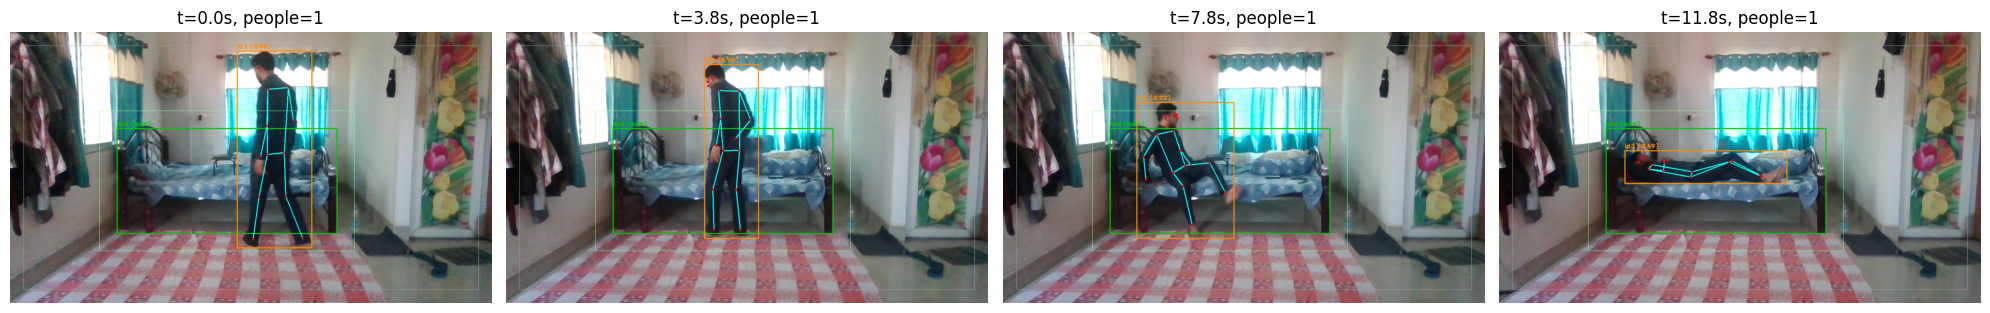

In [27]:
SKELETON = [
    ("l_shoulder", "r_shoulder"), ("l_shoulder", "l_elbow"), ("l_elbow", "l_wrist"),
    ("r_shoulder", "r_elbow"), ("r_elbow", "r_wrist"), ("l_shoulder", "l_hip"),
    ("r_shoulder", "r_hip"), ("l_hip", "r_hip"), ("l_hip", "l_knee"), ("l_knee", "l_ankle"),
    ("r_hip", "r_knee"), ("r_knee", "r_ankle"),
]

def draw_persons(img: np.ndarray, rows: pd.DataFrame, kp_min_conf: float = 0.3) -> np.ndarray:
    """Draw boxes, track IDs and skeletons."""
    out = img.copy()
    for _, r in rows.iterrows():
        color = (0, 140, 255) if r["track_id"] >= 0 else (128, 128, 128)
        cv2.rectangle(out, (int(r["x1"]), int(r["y1"])), (int(r["x2"]), int(r["y2"])), color, 2)
        cv2.putText(out, f"id {r['track_id']} ({r['conf']:.2f})", (int(r["x1"]), max(15, int(r["y1"]) - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        for a, b in SKELETON:
            if r[f"{a}_c"] >= kp_min_conf and r[f"{b}_c"] >= kp_min_conf:
                cv2.line(out, (int(r[f"{a}_x"]), int(r[f"{a}_y"])),
                         (int(r[f"{b}_x"]), int(r[f"{b}_y"])), (255, 255, 0), 2)
        for name in KEYPOINT_NAMES:
            if r[f"{name}_c"] >= kp_min_conf:
                cv2.circle(out, (int(r[f"{name}_x"]), int(r[f"{name}_y"])), 3, (0, 0, 255), -1)
    return out

# Show 4 frames spread over the video
pick = np.linspace(0, len(frames_df) - 1, 4).astype(int)
wanted = set(frames_df.loc[pick, "sample_idx"])
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
i = 0
for f in sample_frames(info, cfg.sample_fps, cfg.max_side):
    if f.sample_idx in wanted:
        rows = persons_df[persons_df["sample_idx"] == f.sample_idx]
        img = draw_persons(draw_scene(f.image, scene), rows)
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"t={f.t_sec:.1f}s, people={len(rows)}")
        axes[i].axis("off")
        i += 1
plt.tight_layout()
plt.show()

## 3.9: Signal plot

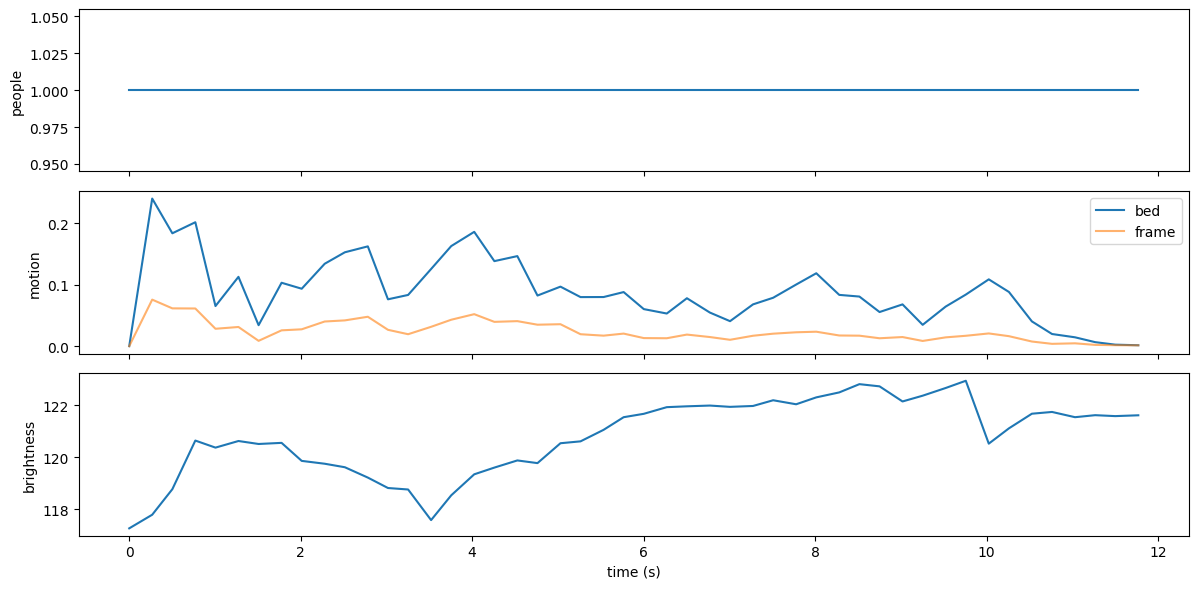

In [28]:
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axes[0].plot(frames_df["t_sec"], frames_df["n_persons"], drawstyle="steps-post")
axes[0].set_ylabel("people")
axes[1].plot(frames_df["t_sec"], frames_df["bed_motion"], label="bed")
axes[1].plot(frames_df["t_sec"], frames_df["frame_motion"], label="frame", alpha=0.6)
axes[1].set_ylabel("motion"); axes[1].legend()
axes[2].plot(frames_df["t_sec"], frames_df["brightness"])
axes[2].set_ylabel("brightness"); axes[2].set_xlabel("time (s)")
plt.tight_layout()
plt.show()

# 04. Patient Features

## 4.1: Feature config

In [29]:
feat_log = logging.getLogger("bedmonitor.features")

@dataclass
class FeatureConfig:
    min_person_conf: float = 0.3     # ignore weaker person detections
    kp_min_conf: float = 0.3         # keypoints below this count as not visible
    min_track_frames: int = 3        # shorter tracks are treated as noise
    relink_gap_sec: float = 5.0      # max gap to join two tracks by position
    relink_dist_ratio: float = 1.0   # max jump between tracks, as a fraction of box height
    overlap_tol_sec: float = 1.0     # tracks that overlap longer than this are different people
    speed_window_sec: float = 1.0    # speed is measured over this window
    scale_smooth_sec: float = 2.0    # smoothing window for body size
    alone_near_bed_frac: float = 0.5 # a lone new track this often near the bed is the returning patient

    def save(self, path):
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2))
        feat_log.info("Feature config saved to %s", path)

fcfg = FeatureConfig()

## 4.2: Angle helpers

In [30]:
def side_avg(df: pd.DataFrame, part: str, axis: str, kp_min: float) -> pd.Series:
    """Average of the left and right keypoint (e.g. hips), using only visible sides. NaN if neither is visible."""
    left = df[f"l_{part}_{axis}"].where(df[f"l_{part}_c"] >= kp_min)
    right = df[f"r_{part}_{axis}"].where(df[f"r_{part}_c"] >= kp_min)
    return pd.concat([left, right], axis=1).mean(axis=1)

def angle_from_vertical(dx, dy):
    """Angle of a line from vertical: 0 = upright, 90 = horizontal."""
    length = np.hypot(dx, dy)
    with np.errstate(invalid="ignore", divide="ignore"):
        # abs(dy) use in the torso angle, so the direction of the body does not matter. A person lying head-left and a person lying head-right both get 90°.
        return np.degrees(np.arccos(np.clip(np.abs(dy) / length, 0, 1))) 

def joint_angle(df: pd.DataFrame, a: str, b: str, c: str, kp_min: float) -> pd.Series:
    """Angle at joint b between b->a and b->c, in degrees (180 = straight). Averages left and right sides."""
    sides = []
    for s in ("l", "r"):
        ok = (df[f"{s}_{a}_c"] >= kp_min) & (df[f"{s}_{b}_c"] >= kp_min) & (df[f"{s}_{c}_c"] >= kp_min)
        v1x, v1y = df[f"{s}_{a}_x"] - df[f"{s}_{b}_x"], df[f"{s}_{a}_y"] - df[f"{s}_{b}_y"]
        v2x, v2y = df[f"{s}_{c}_x"] - df[f"{s}_{b}_x"], df[f"{s}_{c}_y"] - df[f"{s}_{b}_y"]
        with np.errstate(invalid="ignore", divide="ignore"):
            cos = (v1x * v2x + v1y * v2y) / (np.hypot(v1x, v1y) * np.hypot(v2x, v2y))
        sides.append(pd.Series(np.degrees(np.arccos(np.clip(cos, -1, 1))), index=df.index).where(ok))
    return pd.concat(sides, axis=1).mean(axis=1)

## 4.3: Geometry for every person row

In [31]:
def add_geometry(persons: pd.DataFrame, scene: Scene, fcfg: FeatureConfig) -> pd.DataFrame:
    """Body geometry and zone features for every person row."""
    df = persons[(persons["conf"] >= fcfg.min_person_conf) & (~persons["in_tv_zone"].astype(bool))].copy()
    dropped = len(persons) - len(df)
    if dropped:
        feat_log.info("Dropped %d person rows (low confidence or on a TV)", dropped)
    if df.empty:
        feat_log.warning("No person rows left after filtering")
        return df
    k = fcfg.kp_min_conf

    # Body points (average of visible left/right sides)
    for part, short in [("shoulder", "sh"), ("hip", "hip"), ("knee", "knee"), ("ankle", "ank")]:
        df[f"{short}_x"] = side_avg(df, part, "x", k)
        df[f"{short}_y"] = side_avg(df, part, "y", k)

    # Box shape
    df["box_w"] = df["x2"] - df["x1"]
    df["box_h"] = df["y2"] - df["y1"]
    df["box_cx"] = (df["x1"] + df["x2"]) / 2
    df["box_cy"] = (df["y1"] + df["y2"]) / 2
    df["aspect"] = df["box_w"] / df["box_h"]          # > 1 means wider than tall

    # Posture angles
    df["torso_len"] = np.hypot(df["sh_x"] - df["hip_x"], df["sh_y"] - df["hip_y"])
    df["torso_angle"] = angle_from_vertical(df["sh_x"] - df["hip_x"], df["sh_y"] - df["hip_y"])
    df["thigh_angle"] = angle_from_vertical(df["knee_x"] - df["hip_x"], df["knee_y"] - df["hip_y"])
    df["knee_angle"] = joint_angle(df, "hip", "knee", "ankle", k)

    # Keypoint visibility
    conf_cols = [f"{n}_c" for n in KEYPOINT_NAMES]
    df["kp_mean_conf"] = df[conf_cols].mean(axis=1)
    df["n_kp_visible"] = (df[conf_cols] >= k).sum(axis=1)

    # Location point: hips if visible, else box center
    has_hip = df["hip_x"].notna()
    df["loc_x"] = df["hip_x"].where(has_hip, df["box_cx"])
    df["loc_y"] = df["hip_y"].where(has_hip, df["box_cy"])
    df["loc_src"] = np.where(has_hip, "hip", "box")

    # Position relative to the bed
    bx1, by1, bx2, by2 = scene.bed_box
    m = scene.bed_edge_margin_px
    df["bed_dist"] = [signed_distance((x, y), scene.bed_polygon) for x, y in zip(df["loc_x"], df["loc_y"])]
    df["bed_zone"] = np.select(
        [df["bed_dist"] >= m, df["bed_dist"] >= -m], ["inside", "edge"], default="outside"
    )
    df["hip_rel_y"] = (df["loc_y"] - by1) / (by2 - by1)   # 0 = bed top line, 1 = bed bottom line
    feet_y = df["ank_y"].where(df["ank_y"].notna(), df["y2"])
    df["feet_rel_y"] = (feet_y - by1) / (by2 - by1)

    # Chair, exit and frame-border checks
    df["in_chair"] = [
        any(in_zone((x, y), box_to_polygon(c["box"]), margin=10) for c in scene.chairs)
        for x, y in zip(df["loc_x"], df["loc_y"])
    ]
    # HEre, at_border means the box touches the frame edge. Like a person leaving the view is cut off at the edge first, so this is an early "leaving" signal.
    df["at_border"] = (df["x1"] <= 2) | (df["y1"] <= 2) | (df["x2"] >= scene.frame_w - 2) | (df["y2"] >= scene.frame_h - 2)
    center_in_exit = pd.Series(
        [in_exit_zone((x, y), scene) for x, y in zip(df["box_cx"], df["box_cy"])], index=df.index
    )
    df["in_exit"] = center_in_exit | df["at_border"]
    return df

## 4.4: Track summary and patient selection

In [32]:
def summarize_tracks(geo: pd.DataFrame) -> pd.DataFrame:
    """One row per track: when it was seen, where it started and ended."""
    rows = []
    for tid, g in geo[geo["track_id"] >= 0].groupby("track_id"):
        g = g.sort_values("t_sec")
        head, tail = g.head(3), g.tail(3)
        rows.append({
            "track_id": int(tid),
            "start_t": float(g["t_sec"].iloc[0]),
            "end_t": float(g["t_sec"].iloc[-1]),
            "n_frames": len(g),
            "mean_conf": float(g["conf"].mean()),
            "near_bed_frac": float((g["bed_zone"] != "outside").mean()),
            "start_in_bed": bool((head["bed_zone"] != "outside").mean() >= 0.5),
            "end_in_bed": bool((tail["bed_zone"] != "outside").mean() >= 0.5),
            "start_in_exit": bool(head["in_exit"].any()),
            "end_in_exit": bool(tail["in_exit"].any()),
            "start_x": float(g["loc_x"].iloc[0]), "start_y": float(g["loc_y"].iloc[0]),
            "end_x": float(g["loc_x"].iloc[-1]), "end_y": float(g["loc_y"].iloc[-1]),
            "box_h": float(g["box_h"].median()),
        })
    return pd.DataFrame(rows)

def overlap_sec(a, b) -> float:
    return min(a["end_t"], b["end_t"]) - max(a["start_t"], b["start_t"])

def link_reason(earlier, later, summary: pd.DataFrame, fcfg: FeatureConfig) -> str | None:
    """Return why `later` is the same person as `earlier`, or None."""
    gap = later["start_t"] - earlier["end_t"]
    if gap < -fcfg.overlap_tol_sec:
        return None
    jump = np.hypot(later["start_x"] - earlier["end_x"], later["start_y"] - earlier["end_y"])
    if gap <= fcfg.relink_gap_sec and jump <= fcfg.relink_dist_ratio * max(earlier["box_h"], later["box_h"]):
        return "short_gap_near"
    if earlier["end_in_bed"] and later["start_in_bed"]:
        return "same_bed_spot"
    others_at_start = summary[
        (summary["track_id"] != later["track_id"])
        & (summary["start_t"] <= later["start_t"]) & (summary["end_t"] >= later["start_t"])
    ]
    if earlier["end_in_exit"] and later["start_in_exit"] and others_at_start.empty:
        return "returned_via_exit"
    if others_at_start.empty and later["near_bed_frac"] >= fcfg.alone_near_bed_frac:
        return "alone_near_bed"     # only person in view, and spends most of its time near the bed
    return None

def select_patient(summary: pd.DataFrame, fcfg: FeatureConfig) -> pd.DataFrame:
    """Score tracks, pick the patient, then join later/earlier tracks of the same person."""
    s = summary[summary["n_frames"] >= fcfg.min_track_frames].copy()
    if s.empty:
        feat_log.warning("No track is long enough to be the patient")
        return summary.assign(score=np.nan, role="noise", link="")

    s["score"] = (
        2.0 * s["start_in_bed"] + 2.0 * s["near_bed_frac"]
        + 1.0 * s["n_frames"] / s["n_frames"].max() - 1.0 * s["start_in_exit"]
    )
    anchor = s.loc[s["score"].idxmax()]
    links = {int(anchor["track_id"]): "anchor"}

    def patient_rows():
        return s[s["track_id"].isin(links)]

    def overlaps_patient(t) -> bool:
        return any(overlap_sec(t, p) > fcfg.overlap_tol_sec for _, p in patient_rows().iterrows())

    # Forward: tracks that start after the anchor
    for _, t in s.sort_values("start_t").iterrows():
        if t["track_id"] in links or t["start_t"] < anchor["start_t"] or overlaps_patient(t):
            continue
        before = patient_rows()[patient_rows()["end_t"] <= t["start_t"] + fcfg.overlap_tol_sec]
        if before.empty:
            continue
        reason = link_reason(before.loc[before["end_t"].idxmax()], t, s, fcfg)
        if reason:
            links[int(t["track_id"])] = reason

    # Backward: tracks that start before the anchor
    for _, t in s.sort_values("end_t", ascending=False).iterrows():
        if t["track_id"] in links or t["start_t"] >= anchor["start_t"] or overlaps_patient(t):
            continue
        after = patient_rows()[patient_rows()["start_t"] >= t["end_t"] - fcfg.overlap_tol_sec]
        if after.empty:
            continue
        reason = link_reason(t, after.loc[after["start_t"].idxmin()], s, fcfg)
        if reason:
            links[int(t["track_id"])] = reason

    out = summary.merge(s[["track_id", "score"]], on="track_id", how="left")
    out["role"] = np.where(out["track_id"].isin(links), "patient",
                           np.where(out["n_frames"] >= fcfg.min_track_frames, "other", "noise"))
    out["link"] = out["track_id"].map(links).fillna("")
    return out.sort_values("start_t").reset_index(drop=True)

## 4.5: Patient feature table

In [33]:
def build_patient_features(geo: pd.DataFrame, frames_df: pd.DataFrame, tracks: pd.DataFrame,
                           scene: Scene, fcfg: FeatureConfig, sample_fps: float) -> pd.DataFrame:
    """One row per sampled frame with the patient's features (NaN when the patient is not seen)."""
    patient_ids = tracks.loc[tracks["role"] == "patient", "track_id"].tolist()
    other_ids = tracks.loc[tracks["role"] == "other", "track_id"].tolist()

    # Patient row per frame (if two patient rows exist in one frame, keep the most confident)
    pat = (geo[geo["track_id"].isin(patient_ids)]
           .sort_values(["sample_idx", "conf"], ascending=[True, False])
           .drop_duplicates("sample_idx"))
    keep = ["sample_idx", "track_id", "conf", "x1", "y1", "x2", "y2", "box_w", "box_h", "aspect",
            "kp_mean_conf", "n_kp_visible", "torso_len", "torso_angle", "thigh_angle", "knee_angle",
            "hip_x", "hip_y", "box_cx", "box_cy", "loc_x", "loc_y", "loc_src", "bed_dist", "bed_zone",
            "hip_rel_y", "feet_rel_y", "in_chair", "in_exit", "at_border"]
    base_cols = ["sample_idx", "t_sec", "brightness", "enhanced", "frame_motion", "bed_motion", "n_persons"]
    feat = frames_df[base_cols].merge(pat[keep], on="sample_idx", how="left")
    feat["visible"] = feat["track_id"].notna()
    for col in ["in_chair", "in_exit", "at_border"]:
        feat[col] = feat[col].astype("boolean").fillna(False).astype(bool)

    # Other people (caregivers, visitors)
    others = geo[geo["track_id"].isin(other_ids)]
    feat["n_others"] = feat["sample_idx"].map(others.groupby("sample_idx").size()).fillna(0).astype(int)
    feat["caregiver_present"] = feat["n_others"] > 0

    # Bed motion that no visible person explains (useful when the patient is hidden under a blanket)
    bed_box = scene.bed_box
    on_bed = geo[[box_iou((r.x1, r.y1, r.x2, r.y2), bed_box) > 0.05 for r in geo.itertuples()]]
    person_on_bed = feat["sample_idx"].isin(on_bed["sample_idx"])
    feat["bed_motion_unexplained"] = feat["bed_motion"].where(~person_on_bed)

    # Body scale: smoothed torso length, so speed works at any distance from the camera
    win = max(1, int(round(fcfg.scale_smooth_sec * sample_fps)))
    torso = feat["torso_len"].rolling(win, center=True, min_periods=1).median()
    fallback = 0.3 * feat[["box_w", "box_h"]].max(axis=1)
    feat["body_scale"] = torso.fillna(fallback)
    feat["bed_dist_norm"] = feat["bed_dist"] / feat["body_scale"]

    # Speed in torso lengths per second, over a fixed window. Same point type at both ends.
    k = max(1, int(round(fcfg.speed_window_sec * sample_fps)))
    dt = feat["t_sec"] - feat["t_sec"].shift(k)
    def speed_of(xc, yc):
        return np.hypot(feat[xc] - feat[xc].shift(k), feat[yc] - feat[yc].shift(k)) / dt / feat["body_scale"]
    feat["speed"] = speed_of("hip_x", "hip_y").fillna(speed_of("box_cx", "box_cy"))

    # Memory for gaps: when the patient is not seen, where and when were they last seen?
    feat["last_seen_t"] = feat["t_sec"].where(feat["visible"]).ffill()
    feat["gap_sec"] = feat["t_sec"] - feat["last_seen_t"]
    feat["last_bed_zone"] = feat["bed_zone"].ffill()
    feat["last_in_exit"] = feat["in_exit"].where(feat["visible"]).ffill().astype("boolean")
    return feat

## 4.6: Run the layer

In [34]:
def run_features(persons_df, frames_df, scene, fcfg, cfg, out_dir: Path):
    geo = add_geometry(persons_df, scene, fcfg)
    tracks = summarize_tracks(geo) if not geo.empty else pd.DataFrame()
    if tracks.empty:
        feat_log.error("No tracked people. Check the perception output.")
        raise ValueError("No tracks")

    tracks = select_patient(tracks, fcfg)
    for _, t in tracks.iterrows():
        feat_log.info(
            "Track %d: %s %s, %.1f-%.1fs, %d frames, near bed %.0f%%, score %s",
            t["track_id"], t["role"].upper(), f"({t['link']})" if t["link"] else "",
            t["start_t"], t["end_t"], t["n_frames"], 100 * t["near_bed_frac"],
            "-" if pd.isna(t["score"]) else f"{t['score']:.2f}",
        )

    feat = build_patient_features(geo, frames_df, tracks, scene, fcfg, cfg.sample_fps)

    n = len(feat)
    feat_log.info("Patient visible in %d/%d frames (%.0f%%)", feat["visible"].sum(), n, 100 * feat["visible"].mean())
    feat_log.info("Frames with another person: %d", int(feat["caregiver_present"].sum()))
    feat_log.info("Location from hips: %.0f%% of visible frames",
                  100 * (feat.loc[feat["visible"], "loc_src"] == "hip").mean() if feat["visible"].any() else 0)
    feat_log.info("Bed zone counts: %s", feat["bed_zone"].value_counts().to_dict())
    if feat["visible"].any():
        feat_log.info("Max gap without the patient: %.1f s", feat["gap_sec"].max())

    out_dir.mkdir(parents=True, exist_ok=True)
    feat.to_parquet(out_dir / "features.parquet", index=False)
    tracks.to_csv(out_dir / "tracks.csv", index=False)
    fcfg.save(out_dir / "feature_config.json")
    feat_log.info("Saved features.parquet and tracks.csv to %s", out_dir)
    return feat, tracks

features_df, tracks_df = run_features(persons_df, frames_df, scene, fcfg, cfg, video_out)

display(tracks_df[["track_id", "role", "link", "start_t", "end_t", "n_frames", "near_bed_frac", "score"]])
show_cols = ["t_sec", "visible", "torso_angle", "thigh_angle", "knee_angle",
             "bed_zone", "hip_rel_y", "feet_rel_y", "speed", "kp_mean_conf"]
display(features_df[show_cols].iloc[::4].round(2))

05:30:25 | INFO    | bedmonitor.features | Track 1: PATIENT (anchor), 0.0-11.8s, 48 frames, near bed 100%, score 5.00
05:30:25 | INFO    | bedmonitor.features | Patient visible in 48/48 frames (100%)
05:30:25 | INFO    | bedmonitor.features | Frames with another person: 0
05:30:25 | INFO    | bedmonitor.features | Location from hips: 100% of visible frames
05:30:25 | INFO    | bedmonitor.features | Bed zone counts: {'inside': 44, 'edge': 4}
05:30:25 | INFO    | bedmonitor.features | Max gap without the patient: 0.0 s
05:30:25 | INFO    | bedmonitor.features | Feature config saved to /kaggle/working/outputs/0000/feature_config.json
05:30:25 | INFO    | bedmonitor.features | Saved features.parquet and tracks.csv to /kaggle/working/outputs/0000


,track_id,role,link,start_t,end_t,n_frames,near_bed_frac,score
0,1,patient,anchor,0.0,11.77,48,1.0,5.0


,t_sec,visible,torso_angle,thigh_angle,knee_angle,bed_zone,hip_rel_y,feet_rel_y,speed,kp_mean_conf
0,0.00,True,2.10,4.44,168.47,inside,0.24,1.05,NaN,0.71
4,1.01,True,31.08,3.69,164.44,edge,0.17,0.92,1.09,0.85
8,2.01,True,28.26,0.00,170.45,inside,0.18,0.91,0.04,0.87
12,3.02,True,10.65,7.09,173.64,inside,0.19,0.98,0.53,0.77
16,4.02,True,3.21,7.00,159.16,inside,0.21,0.95,0.42,0.73
20,5.03,True,52.86,10.94,163.18,inside,0.20,0.92,0.44,0.87
24,6.00,True,31.28,18.33,163.45,inside,0.34,0.92,0.48,0.86
28,7.01,True,1.17,23.12,158.86,inside,0.40,0.92,0.21,0.96
32,8.01,True,26.64,85.68,132.85,inside,0.39,0.64,0.21,0.83
36,9.02,True,35.86,52.00,81.22,inside,0.37,0.45,0.38,0.80


## 4.7: Feature plot

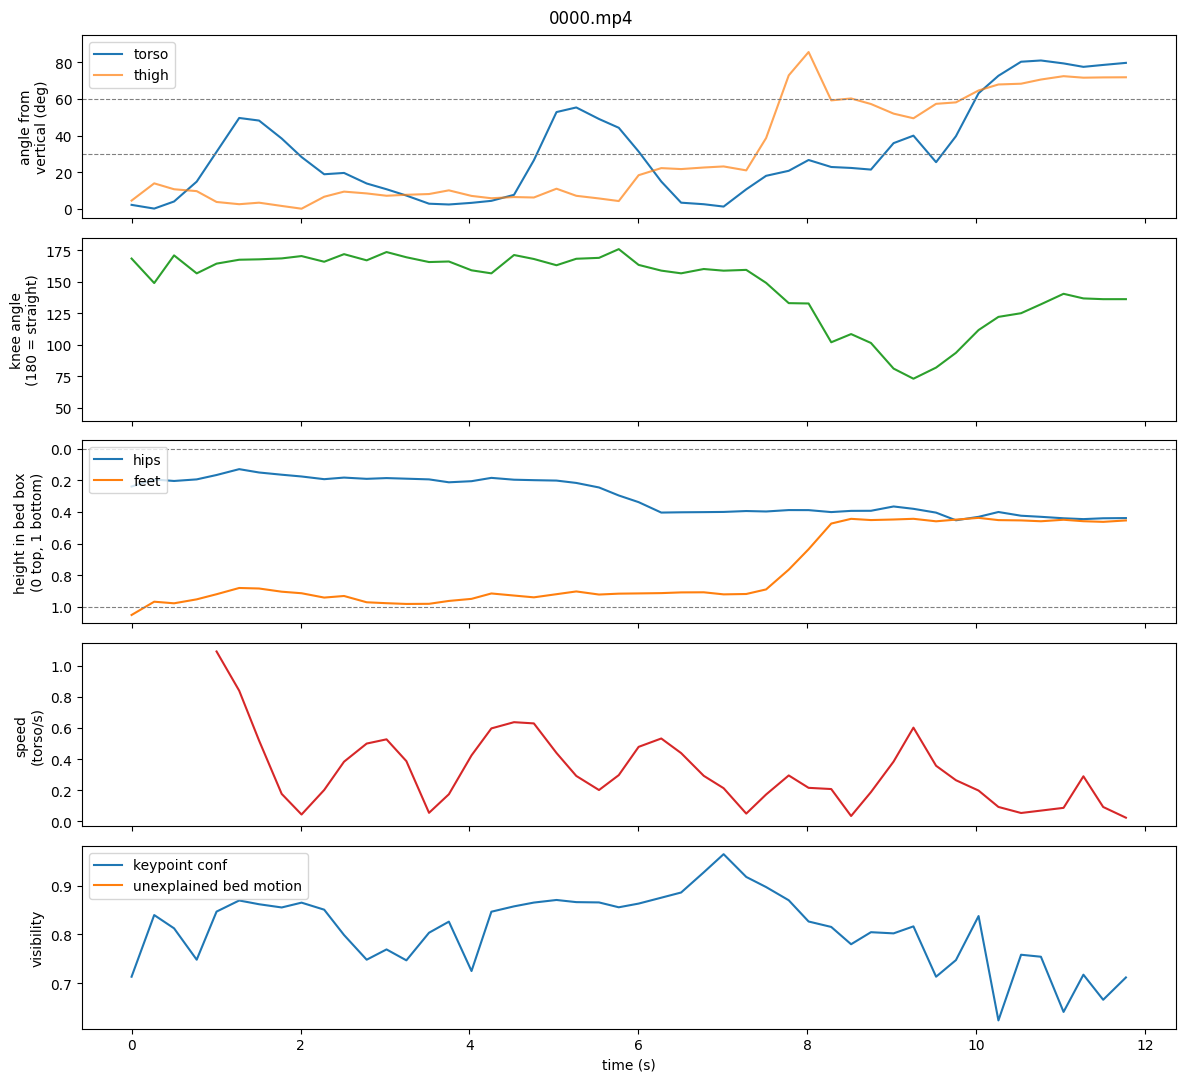

In [35]:
def plot_features(feat: pd.DataFrame, sample_fps: float, title: str = ""):
    """Plot the main features over time. Gray bands = patient not visible."""
    t = feat["t_sec"]
    half = 0.5 / sample_fps
    fig, axes = plt.subplots(5, 1, figsize=(12, 11), sharex=True)

    axes[0].plot(t, feat["torso_angle"], label="torso")
    axes[0].plot(t, feat["thigh_angle"], label="thigh", alpha=0.7)
    axes[0].axhline(30, ls="--", c="gray", lw=0.8)
    axes[0].axhline(60, ls="--", c="gray", lw=0.8)
    axes[0].set_ylabel("angle from\nvertical (deg)"); axes[0].set_ylim(-5, 95); axes[0].legend(loc="upper left")

    axes[1].plot(t, feat["knee_angle"], c="tab:green")
    axes[1].set_ylabel("knee angle\n(180 = straight)"); axes[1].set_ylim(40, 185)

    axes[2].plot(t, feat["hip_rel_y"], label="hips")
    axes[2].plot(t, feat["feet_rel_y"], label="feet")
    axes[2].axhline(0, ls="--", c="gray", lw=0.8)
    axes[2].axhline(1, ls="--", c="gray", lw=0.8)
    axes[2].invert_yaxis()
    axes[2].set_ylabel("height in bed box\n(0 top, 1 bottom)"); axes[2].legend(loc="upper left")

    axes[3].plot(t, feat["speed"], c="tab:red")
    axes[3].set_ylabel("speed\n(torso/s)")

    axes[4].plot(t, feat["kp_mean_conf"], label="keypoint conf")
    axes[4].plot(t, feat["bed_motion_unexplained"], label="unexplained bed motion")
    axes[4].set_ylabel("visibility"); axes[4].set_xlabel("time (s)"); axes[4].legend(loc="upper left")

    for ax in axes:
        for ts in t[~feat["visible"]]:
            ax.axvspan(ts - half, ts + half, color="gray", alpha=0.2, lw=0)
    fig.suptitle(title)
    plt.tight_layout()
    return fig

fig = plot_features(features_df, cfg.sample_fps, title=Path(info.path).name)
fig.savefig(video_out / "features_plot.png", dpi=100)
plt.show()

# 05. Temporal State Tracker

## 5.1: State config

In [36]:
from dataclasses import dataclass, asdict, field

state_log = logging.getLogger("bedmonitor.states")

STATES = [
    "LYING_IN_BED", "SITTING_ON_BED", "SITTING_OUTSIDE_BED", "STANDING",
    "WALKING", "LYING_OUTSIDE_BED", "OUT_OF_BED", "UNKNOWN",
]
VISIBLE_STATES = STATES[:6]          # states we can see directly
IN_BED_STATES = {"LYING_IN_BED", "SITTING_ON_BED"}

@dataclass
class StateConfig:
    # Posture (centers of soft thresholds)
    torso_upright_max: float = 45.0   # torso angle below this = upright
    torso_lying_min: float = 55.0     # torso angle above this = horizontal
    torso_sit_max: float = 70.0       # sitting can lean back up to about this
    knee_straight_min: float = 145.0
    knee_bent_max: float = 125.0
    leg_drop_stand: float = 1.2       # feet this many torso lengths below hips = standing
    leg_drop_flat: float = 0.6        # below this = legs flat (lying)
    walk_speed: float = 0.4           # torso lengths per second
    floor_hip_rel_y: float = 0.8      # lying with hips this low in the bed box = maybe the floor
    # Evidence strength
    kp_conf_low: float = 0.35         # keypoint confidence where evidence starts to count
    kp_conf_full: float = 0.65        # keypoint confidence where evidence counts fully
    # Patient not visible
    exit_gap_sec: float = 2.0         # hidden this long after an exit = OUT_OF_BED
    unknown_gap_sec: float = 5.0      # hidden this long (not near exit) = UNKNOWN
    hidden_in_bed_gap_sec: float = 30.0  # last seen in bed: wait longer (likely under a blanket)
    hidden_bed_motion: float = 0.02   # unexplained bed motion above this supports "still in bed"
    # HMM
    switch_tau_sec: float = 8.0       # average time between state changes; larger = fewer changes
    rare_weight: float = 0.2          # weight of unusual (but possible) transitions
    min_dwell_sec: dict = field(default_factory=lambda: {
        "LYING_IN_BED": 3.0, "SITTING_ON_BED": 2.0, "SITTING_OUTSIDE_BED": 2.0, "STANDING": 1.0,
        "WALKING": 2.0, "LYING_OUTSIDE_BED": 0.0, "OUT_OF_BED": 2.0, "UNKNOWN": 1.0,
    })
    # Doubt flags
    low_conf: float = 0.6             # segments with mean confidence below this are flagged

    def save(self, path):
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2))
        state_log.info("State config saved to %s", path)

scfg_states = StateConfig()

## 5.2: Soft rules and leg drop

In [37]:
def soft_above(x, center: float, width: float) -> np.ndarray:
    """Smooth step: about 0 well below `center`, 1 well above it, 0.5 at `center`. NaN gives 0.5 (no opinion)."""
    x = np.asarray(x, dtype=float)
    with np.errstate(over="ignore"):
        out = 1.0 / (1.0 + np.exp(-(x - center) / width))
    return np.where(np.isnan(x), 0.5, out)

def soft_below(x, center: float, width: float) -> np.ndarray:
    return 1.0 - soft_above(x, center, width)

def add_leg_drop(feat: pd.DataFrame, scene) -> pd.Series:
    """Vertical distance from hips to feet, in torso lengths. Standing is large, lying is near 0."""
    by1, by2 = scene.bed_box[1], scene.bed_box[3]
    return (feat["feet_rel_y"] - feat["hip_rel_y"]) * (by2 - by1) / feat["body_scale"]

## 5.3: State scorer

In [38]:
def score_states(feat: pd.DataFrame, scene, c: StateConfig) -> pd.DataFrame:
    """
    Per-frame evidence for each state (the HMM 'emission' scores).
    Each score combines soft rules. Posture comes first; location only splits posture into states.
    """
    torso, knee, speed = feat["torso_angle"], feat["knee_angle"], feat["speed"]
    drop = add_leg_drop(feat, scene)

    # Posture
    up = soft_below(torso, c.torso_upright_max, 7)
    horiz = soft_above(torso, c.torso_lying_min, 7)
    recline_ok = soft_below(torso, c.torso_sit_max, 7)
    straight = soft_above(knee, c.knee_straight_min, 10)
    bent = soft_below(knee, c.knee_bent_max, 10)
    tall = soft_above(drop, c.leg_drop_stand, 0.15)
    flat = soft_below(drop, c.leg_drop_flat, 0.15)
    mid = (1 - tall) * (1 - flat)

    upright = up * (0.7 * tall + 0.3 * straight)
    sitting = recline_ok * (0.7 * mid + 0.3 * bent)
    lying = horiz * (0.5 + 0.5 * flat)
    moving = soft_above(speed, c.walk_speed, 0.1)

    # Location
    in_bed = feat["bed_zone"].map({"inside": 0.95, "edge": 0.75, "outside": 0.05}).fillna(0.5).to_numpy()
    chair = np.where(feat["in_chair"], 0.9, 0.0)
    bed_for_lying = in_bed * soft_below(feat["hip_rel_y"], c.floor_hip_rel_y, 0.05)

    raw = pd.DataFrame({
        "LYING_IN_BED": lying * bed_for_lying,
        "LYING_OUTSIDE_BED": lying * (1 - bed_for_lying),
        "SITTING_ON_BED": sitting * in_bed * (1 - chair),
        "SITTING_OUTSIDE_BED": sitting * np.maximum(1 - in_bed, chair),
        "STANDING": upright * (1 - moving),
        "WALKING": upright * moving,
    }, index=feat.index)
    probs = raw.div(raw.sum(axis=1).replace(0, np.nan), axis=0).fillna(1 / len(VISIBLE_STATES))

    # Evidence strength from keypoint confidence: weak evidence spreads out evenly
    q = np.clip((feat["kp_mean_conf"].fillna(0) - c.kp_conf_low) / (c.kp_conf_full - c.kp_conf_low), 0, 1)
    em = probs.mul(q, axis=0).add((1 - q) / len(VISIBLE_STATES), axis=0)
    em["UNKNOWN"] = 0.05 + 0.4 * (1 - q)
    em["OUT_OF_BED"] = 0.005

    # Frames where the patient is not visible
    hidden = ~feat["visible"].to_numpy()
    if hidden.any():
        gap = feat["gap_sec"].fillna(1e6).to_numpy()   # never seen yet = very long gap
        last_exit = feat["last_in_exit"].fillna(False).astype(bool).to_numpy()
        last_in_bed = feat["last_bed_zone"].isin(["inside", "edge"]).to_numpy()
        bed_moves = feat["bed_motion_unexplained"].fillna(0).to_numpy() > c.hidden_bed_motion

        g_exit = last_exit * soft_above(gap, c.exit_gap_sec, 0.5)
        unk_after = np.where(last_in_bed & ~last_exit, c.hidden_in_bed_gap_sec, c.unknown_gap_sec)
        g_unk = soft_above(gap - unk_after, 0, 1.0) * (1 - g_exit)

        flat_val = 0.15
        for s in VISIBLE_STATES:
            em.loc[hidden, s] = flat_val          # flat evidence: the HMM carries the last state forward
        em.loc[hidden, "OUT_OF_BED"] = 0.05 + 0.8 * g_exit[hidden]
        em.loc[hidden, "UNKNOWN"] = 0.05 + 0.6 * g_unk[hidden]
        support = hidden & last_in_bed & bed_moves
        em.loc[support, "LYING_IN_BED"] += 0.3   # bed still moves: likely under a blanket

    em = em[STATES]
    em["leg_drop"] = drop
    em["evidence_q"] = q
    return em

## 5.4: Transitions and the minimum-stay HMM

In [39]:
def allowed_transitions(c: StateConfig) -> dict:
    """Which state can follow which, with a weight. Missing pairs are (almost) impossible."""
    n, r = 1.0, c.rare_weight
    return {
        "LYING_IN_BED":        {"SITTING_ON_BED": n, "UNKNOWN": n, "LYING_OUTSIDE_BED": r},
        "SITTING_ON_BED":      {"LYING_IN_BED": n, "STANDING": n, "UNKNOWN": n, "LYING_OUTSIDE_BED": r},
        "SITTING_OUTSIDE_BED": {"STANDING": n, "UNKNOWN": n, "WALKING": r, "LYING_OUTSIDE_BED": r},
        "STANDING":            {"WALKING": n, "SITTING_ON_BED": n, "SITTING_OUTSIDE_BED": n,
                                "OUT_OF_BED": n, "UNKNOWN": n, "LYING_OUTSIDE_BED": r},
        "WALKING":             {"STANDING": n, "SITTING_OUTSIDE_BED": n, "OUT_OF_BED": n, "UNKNOWN": n,
                                "SITTING_ON_BED": r, "LYING_OUTSIDE_BED": r},
        "LYING_OUTSIDE_BED":   {"SITTING_OUTSIDE_BED": n, "STANDING": n, "UNKNOWN": n},
        "OUT_OF_BED":          {"WALKING": n, "STANDING": n, "UNKNOWN": n},
        "UNKNOWN":             {s: n for s in STATES if s != "UNKNOWN"},
    }

def build_hmm(c: StateConfig, sample_fps: float):
    """
    HMM with a minimum stay per state. Each state becomes a chain of k copies:
    copy 1 -> copy 2 -> ... -> copy k (forced), and only copy k can stay or leave.
    So the path cannot leave a state before k frames.
    """
    dt = 1.0 / sample_fps
    p_leave = 1.0 - np.exp(-dt / c.switch_tau_sec)
    trans = allowed_transitions(c)

    nodes = []                      # (state, copy index)
    first, last = {}, {}
    for s in STATES:
        k = max(1, int(round(c.min_dwell_sec.get(s, 0) * sample_fps)))
        first[s] = len(nodes)
        nodes += [(s, i) for i in range(k)]
        last[s] = len(nodes) - 1

    n = len(nodes)
    A = np.full((n, n), 1e-12)
    for s in STATES:
        for i in range(first[s], last[s]):
            A[i, i + 1] = 1.0                       # forced step along the chain
        A[last[s], last[s]] = 1.0 - p_leave         # stay
        total = sum(trans[s].values())
        for t, w in trans[s].items():
            A[last[s], first[t]] = p_leave * w / total
    A /= A.sum(axis=1, keepdims=True)
    node_state = np.array([STATES.index(s) for s, _ in nodes])
    return np.log(A), node_state

## 5.5: Viterbi and confidence

In [40]:
def viterbi(log_em: np.ndarray, log_A: np.ndarray) -> np.ndarray:
    """Most likely node path. log_em: (T, n_nodes)."""
    T, n = log_em.shape
    delta = np.full((T, n), -np.inf)
    back = np.zeros((T, n), dtype=int)
    delta[0] = -np.log(n) + log_em[0]
    for t in range(1, T):
        scores = delta[t - 1][:, None] + log_A
        back[t] = scores.argmax(axis=0)
        delta[t] = scores.max(axis=0) + log_em[t]
    path = np.zeros(T, dtype=int)
    path[-1] = delta[-1].argmax()
    for t in range(T - 1, 0, -1):
        path[t - 1] = back[t, path[t]]
    return path

def forward_backward(log_em: np.ndarray, log_A: np.ndarray) -> np.ndarray:
    """Posterior probability of each node at each frame (used as confidence)."""
    from scipy.special import logsumexp
    T, n = log_em.shape
    fwd = np.zeros((T, n))
    bwd = np.zeros((T, n))
    fwd[0] = -np.log(n) + log_em[0]
    for t in range(1, T):
        fwd[t] = logsumexp(fwd[t - 1][:, None] + log_A, axis=0) + log_em[t]
    for t in range(T - 2, -1, -1):
        bwd[t] = logsumexp(log_A + (log_em[t + 1] + bwd[t + 1])[None, :], axis=1)
    post = fwd + bwd
    post -= logsumexp(post, axis=1, keepdims=True)
    return np.exp(post)

## 5.6: Segments and doubt flags

In [41]:
def make_segments(states_df: pd.DataFrame, feat: pd.DataFrame, c: StateConfig, sample_fps: float) -> pd.DataFrame:
    """Group frames into segments and add doubt flags for the agent."""
    dt = 1.0 / sample_fps
    run_id = (states_df["state"] != states_df["state"].shift()).cumsum()
    rows = []
    prev_state = None
    for _, g in states_df.groupby(run_id, sort=True):
        f = feat.loc[g.index]
        state = g["state"].iloc[0]
        flags = []
        conf = float(g["confidence"].mean())
        if conf < c.low_conf:
            flags.append("low_confidence")
        if prev_state is not None and (prev_state in IN_BED_STATES) != (state in IN_BED_STATES):
            flags.append("bed_status_change")
        if state == "UNKNOWN":
            flags.append("unknown")
        if state == "LYING_OUTSIDE_BED":
            flags.append("possible_floor")
        if (~f["visible"]).mean() > 0.5:
            flags.append("patient_not_visible")
        if f["torso_angle"].between(30, 60).mean() > 0.5:
            flags.append("torso_gray_zone")
        if f["caregiver_present"].any():
            flags.append("other_person_present")
        if state.startswith("LYING") and (f["hip_rel_y"] > c.floor_hip_rel_y).mean() > 0.3 \
                and (f["bed_zone"] != "outside").mean() > 0.5:
            flags.append("pose_location_conflict")
        rows.append({
            "start_t": float(g["t_sec"].iloc[0]),
            "end_t": float(g["t_sec"].iloc[-1] + dt),
            "duration_sec": len(g) * dt,
            "state": state,
            "prev_state": prev_state,
            "confidence": round(conf, 3),
            "n_frames": len(g),
            "flags": ",".join(flags),
        })
        prev_state = state
    return pd.DataFrame(rows)

## 5.7: Run the tracker

In [42]:
def run_state_tracker(feat: pd.DataFrame, scene, c: StateConfig, sample_fps: float, out_dir: Path):
    em = score_states(feat, scene, c)
    log_A, node_state = build_hmm(c, sample_fps)
    state_log.info("HMM: %d states, %d nodes (min-stay chains), switch every ~%.0f s on average",
                   len(STATES), len(node_state), c.switch_tau_sec)

    log_em_states = np.log(np.clip(em[STATES].to_numpy(), 1e-9, None))
    log_em_nodes = log_em_states[:, node_state]          # each copy shares its state's evidence

    path = viterbi(log_em_nodes, log_A)
    post_nodes = forward_backward(log_em_nodes, log_A)
    post_states = np.zeros((len(feat), len(STATES)))
    for j in range(len(STATES)):
        post_states[:, j] = post_nodes[:, node_state == j].sum(axis=1)

    states_df = pd.DataFrame({"sample_idx": feat["sample_idx"], "t_sec": feat["t_sec"]})
    states_df["raw_state"] = em[STATES].idxmax(axis=1)            # per-frame best guess (no smoothing)
    states_df["state"] = [STATES[node_state[i]] for i in path]    # HMM path
    states_df["confidence"] = post_states[np.arange(len(feat)), [STATES.index(s) for s in states_df["state"]]]
    for j, s in enumerate(STATES):
        states_df[f"p_{s}"] = post_states[:, j]
    states_df["leg_drop"] = em["leg_drop"].to_numpy()
    states_df["evidence_q"] = em["evidence_q"].to_numpy()

    segments = make_segments(states_df, feat, c, sample_fps)

    # Logs
    changed = (states_df["raw_state"] != states_df["state"]).mean()
    raw_switches = int((states_df["raw_state"] != states_df["raw_state"].shift()).sum() - 1)
    state_log.info("Raw per-frame switches: %d. After HMM: %d segments (%.0f%% of frames relabeled)",
                   raw_switches, len(segments), 100 * changed)
    for _, s in segments.iterrows():
        state_log.info("  %6.1fs - %6.1fs  %-20s conf %.2f  %s",
                       s["start_t"], s["end_t"], s["state"], s["confidence"],
                       f"[{s['flags']}]" if s["flags"] else "")
    flagged = segments[segments["flags"] != ""]
    state_log.info("Segments flagged for the agent: %d of %d", len(flagged), len(segments))

    out_dir.mkdir(parents=True, exist_ok=True)
    states_df.to_parquet(out_dir / "states.parquet", index=False)
    segments.to_csv(out_dir / "segments.csv", index=False)
    c.save(out_dir / "state_config.json")
    state_log.info("Saved states.parquet and segments.csv to %s", out_dir)
    return states_df, segments

states_df, segments_df = run_state_tracker(features_df, scene, scfg_states, cfg.sample_fps, video_out)
display(segments_df)

05:30:31 | INFO    | bedmonitor.states | HMM: 8 states, 53 nodes (min-stay chains), switch every ~8 s on average
05:30:32 | INFO    | bedmonitor.states | Raw per-frame switches: 11. After HMM: 4 segments (31% of frames relabeled)
05:30:32 | INFO    | bedmonitor.states |      0.0s -    1.8s  WALKING              conf 0.97  
05:30:32 | INFO    | bedmonitor.states |      1.8s -    7.8s  STANDING             conf 0.94  
05:30:32 | INFO    | bedmonitor.states |      7.8s -   10.0s  SITTING_ON_BED       conf 0.96  [bed_status_change]
05:30:32 | INFO    | bedmonitor.states |     10.0s -   12.0s  LYING_IN_BED         conf 0.98  
05:30:32 | INFO    | bedmonitor.states | Segments flagged for the agent: 1 of 4
05:30:32 | INFO    | bedmonitor.states | State config saved to /kaggle/working/outputs/0000/state_config.json
05:30:32 | INFO    | bedmonitor.states | Saved states.parquet and segments.csv to /kaggle/working/outputs/0000


,start_t,end_t,duration_sec,state,prev_state,confidence,n_frames,flags
0,0.000,1.759,1.75,WALKING,NaN,0.973,7,
1,1.777,7.761,6.00,STANDING,WALKING,0.937,24,
2,7.779,10.008,2.25,SITTING_ON_BED,STANDING,0.963,9,bed_status_change
3,10.026,12.020,2.00,LYING_IN_BED,SITTING_ON_BED,0.977,8,


## 5.8: State timeline plot

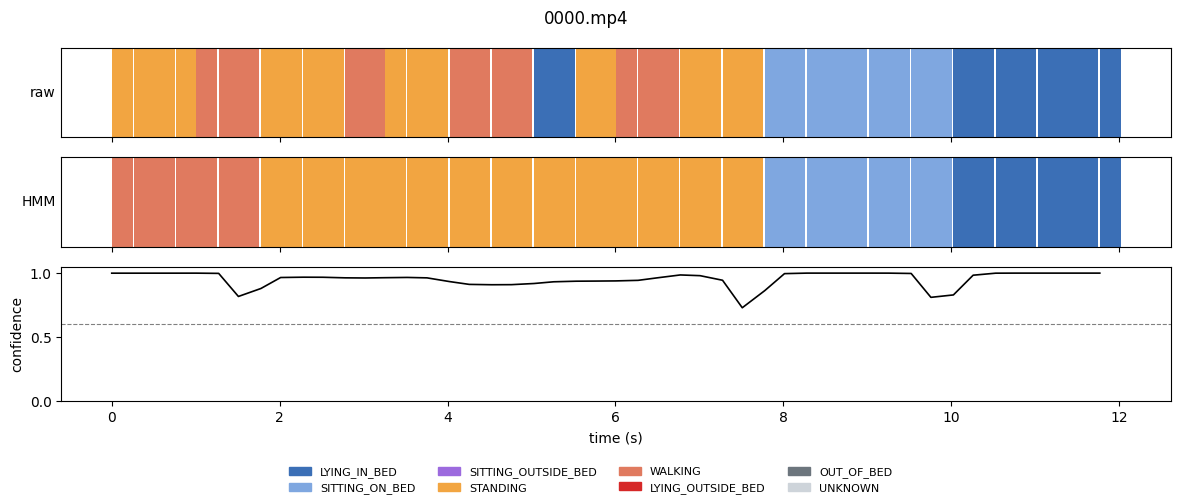

In [43]:
STATE_COLORS = {
    "LYING_IN_BED": "#3B6FB6", "SITTING_ON_BED": "#7FA7E0", "SITTING_OUTSIDE_BED": "#9C6ADE",
    "STANDING": "#F2A541", "WALKING": "#E07A5F", "LYING_OUTSIDE_BED": "#D62828",
    "OUT_OF_BED": "#6C757D", "UNKNOWN": "#CED4DA",
}

def plot_states(states_df: pd.DataFrame, sample_fps: float, title: str = ""):
    """Top: raw per-frame guess. Middle: HMM path. Bottom: confidence."""
    t = states_df["t_sec"].to_numpy()
    dt = 1.0 / sample_fps
    fig, axes = plt.subplots(3, 1, figsize=(12, 5), sharex=True,
                             gridspec_kw={"height_ratios": [1, 1, 1.5]})
    for ax, col, label in [(axes[0], "raw_state", "raw"), (axes[1], "state", "HMM")]:
        for ti, s in zip(t, states_df[col]):
            ax.axvspan(ti, ti + dt, color=STATE_COLORS[s], lw=0)
        ax.set_yticks([]); ax.set_ylabel(label, rotation=0, ha="right", va="center")
    axes[2].plot(t, states_df["confidence"], c="black", lw=1.2, label="confidence")
    axes[2].axhline(0.6, ls="--", c="gray", lw=0.8)
    axes[2].set_ylim(0, 1.05); axes[2].set_ylabel("confidence"); axes[2].set_xlabel("time (s)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=STATE_COLORS[s]) for s in STATES]
    fig.legend(handles, STATES, loc="lower center", ncol=4, fontsize=8, frameon=False)
    fig.suptitle(title)
    plt.tight_layout(rect=(0, 0.08, 1, 1))
    return fig

fig = plot_states(states_df, cfg.sample_fps, title=Path(info.path).name)
fig.savefig(video_out / "states_plot.png", dpi=100)
plt.show()

## 5.9: Calibration table

In [44]:
calib = features_df[["t_sec", "torso_angle", "knee_angle", "hip_rel_y", "feet_rel_y", "speed", "kp_mean_conf"]].copy()
calib["leg_drop"] = states_df["leg_drop"]
calib["body_scale"] = features_df["body_scale"]
calib["raw"] = states_df["raw_state"]
calib["state"] = states_df["state"]
display(calib.iloc[::2].round(2))
display(calib.groupby("state")[["torso_angle", "knee_angle", "leg_drop", "speed"]].median().round(2))

,t_sec,torso_angle,knee_angle,hip_rel_y,feet_rel_y,speed,kp_mean_conf,leg_drop,body_scale,raw,state
0,0.00,2.10,168.47,0.24,1.05,NaN,0.71,1.43,158.46,STANDING,WALKING
2,0.50,3.95,170.99,0.20,0.98,NaN,0.81,1.43,151.37,STANDING,WALKING
4,1.01,31.08,164.44,0.17,0.92,1.09,0.85,1.53,137.41,WALKING,WALKING
6,1.51,48.21,167.86,0.15,0.88,0.52,0.86,1.57,130.29,WALKING,WALKING
8,2.01,28.26,170.45,0.18,0.91,0.04,0.87,1.58,130.29,STANDING,STANDING
10,2.52,19.56,171.96,0.18,0.93,0.38,0.80,1.43,146.02,STANDING,STANDING
12,3.02,10.65,173.64,0.19,0.98,0.53,0.77,1.42,155.35,WALKING,STANDING
14,3.52,2.74,165.71,0.19,0.98,0.05,0.80,1.40,156.79,STANDING,STANDING
16,4.02,3.21,159.16,0.21,0.95,0.42,0.73,1.36,153.24,WALKING,STANDING
18,4.53,7.60,171.28,0.20,0.93,0.64,0.86,1.37,149.16,WALKING,STANDING


,torso_angle,knee_angle,leg_drop,speed
state,,,,
LYING_IN_BED,79.05,134.24,0.05,0.09
SITTING_ON_BED,25.45,101.53,0.17,0.26
STANDING,14.34,166.05,1.42,0.34
WALKING,14.81,167.54,1.43,0.84


# 06. Agent (LangGraph + VLM)

The agent checks only the segments the tracker flagged as doubtful. For each case it loops: **observe → choose a tool → read the finding → decide or ask again**.

- **Tools:** `look_back`, `look_ahead`, `track_history` (cheap, from cached data) and `ask_vlm` (expensive, a closed question to Qwen3-VL).
- **Budget:** at most 4 tool calls and 2 VLM calls per case. If the budget runs out, the case stays unresolved and later gets the decision MONITOR.
- **Planner:** `policy` (fixed steps per case type) is the default. `llm` lets the model choose each step, with the policy as a fallback.
- **Output:** a reasoning trace per case (observation, agent, action, finding, conclusion), and a corrected state path.

## 6.1: Install packages
Qwen3-VL needs a recent `transformers`. If you already imported `transformers` in this session, restart after this cell.

In [45]:
!pip install -q -U langgraph "transformers>=4.57" accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 4.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 100.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.3/162.3 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 67.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.3/125.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 97.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━

## 6.2: Agent config

In [46]:
import re
import json
import time
from dataclasses import dataclass, asdict, field
from typing import TypedDict, Any
import torch
from PIL import Image

agent_log = logging.getLogger("bedmonitor.agent")

@dataclass
class AgentConfig:
    planner: str = "policy"            # "policy" = fixed steps per case type; "llm" = the model picks each step
    vlm_backend: str = "auto"          # "auto" = local model if a GPU exists, else off; "local"; "off"
    vlm_model: str = "Qwen/Qwen3-VL-4B-Instruct"   # "Qwen/Qwen3-VL-2B-Instruct" needs less memory
    vlm_dtype: str = "float16"         # T4 has no bfloat16; use "float32" with the 2B model if answers look broken
    vlm_max_new_tokens: int = 96
    max_tool_calls: int = 4            # per case
    max_vlm_calls: int = 2             # per case
    max_cases: int = 60                # per video
    context_sec: float = 8.0           # how far look_back / look_ahead reach
    vlm_frames: int = 4                # frames per VLM question, tiled 2 per row
    tile_width: int = 480              # width of each tile
    min_vlm_conf: float = 0.6          # VLM answers below this are not trusted
    skip_vlm_conf: float = 0.75        # if context alone gives this confidence, skip the VLM
    short_gap_fill_sec: float = 10.0   # UNKNOWN this short, with the same state on both sides, is filled

    def save(self, path):
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2))
        agent_log.info("Agent config saved to %s", path)

acfg = AgentConfig()

## 6.3: Agent tools
All tools read the cached data. Only `resample_frames` opens the video again, and only for a short window.

In [47]:
OUT_STATES = {"SITTING_OUTSIDE_BED", "STANDING", "WALKING", "LYING_OUTSIDE_BED", "OUT_OF_BED"}
AWAY_STATES = {"WALKING", "OUT_OF_BED", "SITTING_OUTSIDE_BED", "LYING_OUTSIDE_BED"}

@dataclass
class AgentContext:
    states: pd.DataFrame      # frame states from the tracker
    feats: pd.DataFrame       # patient features (same row order)
    tracks: pd.DataFrame      # track summary with roles
    scene: Scene
    info: VideoInfo
    cfg: Config
    acfg: AgentConfig
    out_dir: Path

def summarize_window(ctx: AgentContext, t0: float, t1: float) -> dict:
    """Short summary of the tracker output between t0 and t1."""
    m = (ctx.states["t_sec"] >= t0) & (ctx.states["t_sec"] < t1)
    w, f = ctx.states[m], ctx.feats[m]
    out = {"t0": round(float(t0), 2), "t1": round(float(t1), 2), "n_frames": int(m.sum())}
    if w.empty:
        return out
    shares = w["state"].value_counts(normalize=True)
    known = w.loc[w["state"] != "UNKNOWN", "state"].value_counts(normalize=True)
    seen = f[f["visible"]]
    out.update({
        "dominant_state": str(shares.index[0]),
        "dominant_known_state": str(known.index[0]) if len(known) else None,
        "state_shares": {str(k): round(float(v), 2) for k, v in shares.items()},
        "in_bed_share": round(float(w["state"].isin(IN_BED_STATES).mean()), 2),
        "away_share": round(float(w["state"].isin(AWAY_STATES).mean()), 2),
        "mean_confidence": round(float(w["confidence"].mean()), 2),
        "visible_share": round(float(f["visible"].mean()), 2),
        "hips_outside_bed_share": round(float((f["bed_zone"] == "outside").mean()), 2),
        "max_speed": None if f["speed"].isna().all() else round(float(f["speed"].max()), 2),
        "last_seen_near_exit": bool(seen["in_exit"].iloc[-1]) if len(seen) else None,
        "other_person_share": round(float(f["caregiver_present"].mean()), 2),
    })
    return out

def look_back(ctx: AgentContext, t: float, seconds: float) -> dict:
    return summarize_window(ctx, max(0.0, t - seconds), t)

def look_ahead(ctx: AgentContext, t: float, seconds: float) -> dict:
    end = float(ctx.states["t_sec"].iloc[-1]) + 1e-6
    return summarize_window(ctx, t, min(end, t + seconds))

def describe_window(w: dict, label: str) -> str:
    """Turn a window summary into one readable sentence for the trace."""
    if w.get("n_frames", 0) == 0:
        return f"{label}: no frames in this window."
    top = ", ".join(f"{k} {int(v * 100)}%" for k, v in list(w["state_shares"].items())[:3])
    return (f"{label} ({w['t0']:.1f}-{w['t1']:.1f}s): {top}. "
            f"Visible {int(w['visible_share'] * 100)}%, hips outside bed {int(w['hips_outside_bed_share'] * 100)}%.")

def get_track_history(ctx: AgentContext, t0: float, t1: float) -> dict:
    """Which tracks were active in the window, and where they came from."""
    tr = ctx.tracks
    active = tr[(tr["start_t"] <= t1) & (tr["end_t"] >= t0)]
    items = [{
        "track_id": int(r["track_id"]), "role": r["role"], "link": r["link"],
        "start_t": round(float(r["start_t"]), 1), "end_t": round(float(r["end_t"]), 1),
        "entered_from_exit": bool(r["start_in_exit"]),
    } for _, r in active.iterrows()]
    return {"tracks": items, "n_other": int((active["role"] == "other").sum())}

def resample_frames(ctx: AgentContext, t0: float, t1: float, n: int) -> list:
    """Read n frames spread over [t0, t1] straight from the video (denser than the cached 4 fps if needed)."""
    t0 = max(0.0, float(t0))
    t1 = min(ctx.info.duration_sec, max(float(t1), t0 + 1.0))
    if t1 <= t0:
        return []
    fps = min(ctx.info.fps, max(0.5, n / (t1 - t0)))
    old_level = video_log.level
    video_log.setLevel(logging.WARNING)       # keep the agent logs readable
    try:
        frames = list(sample_frames(ctx.info, fps, ctx.cfg.max_side, t0, t1, log_every_sec=1e9))
    finally:
        video_log.setLevel(old_level)
    if len(frames) > n:
        idx = np.linspace(0, len(frames) - 1, n).round().astype(int)
        frames = [frames[i] for i in idx]
    return frames

def patient_box_at(ctx: AgentContext, t: float):
    i = (ctx.feats["t_sec"] - t).abs().idxmin()
    r = ctx.feats.loc[i]
    return [r["x1"], r["y1"], r["x2"], r["y2"]] if r["visible"] else None

def make_vlm_tile(ctx: AgentContext, frames: list):
    """Draw the bed (green) and patient box (orange) on each frame, add the time, and tile them 2 per row."""
    if not frames:
        return None
    tiles = []
    for f in frames:
        img = f.image.copy()
        cv2.polylines(img, [np.array(ctx.scene.bed_polygon, np.int32)], True, (0, 200, 0), 3)
        box = patient_box_at(ctx, f.t_sec)
        if box is not None:
            cv2.rectangle(img, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), (0, 140, 255), 3)
        cv2.putText(img, f"t={f.t_sec:.1f}s", (12, 44), cv2.FONT_HERSHEY_SIMPLEX, 1.3, (0, 0, 0), 6)
        cv2.putText(img, f"t={f.t_sec:.1f}s", (12, 44), cv2.FONT_HERSHEY_SIMPLEX, 1.3, (255, 255, 255), 2)
        h, w = img.shape[:2]
        tw = ctx.acfg.tile_width
        tiles.append(cv2.resize(img, (tw, int(h * tw / w)), interpolation=cv2.INTER_AREA))
    if len(tiles) % 2:
        tiles.append(np.zeros_like(tiles[0]))
    rows = [np.hstack(tiles[i:i + 2]) for i in range(0, len(tiles), 2)]
    return Image.fromarray(cv2.cvtColor(np.vstack(rows), cv2.COLOR_BGR2RGB))

## 6.4: VLM client
The VLM only answers **closed questions** and must reply in JSON. Every question allows `cannot_tell`, so the model is never forced to guess.

In [48]:
VLM_QUESTIONS = {
    "floor": ("Is the person in the orange box lying on the bed (green outline), lying on the floor, sitting, or standing?",
              ["lying_on_bed", "lying_on_floor", "sitting", "standing", "cannot_tell"]),
    "posture": ("What is the person in the orange box doing in these frames?",
                ["lying", "sitting", "standing", "walking", "cannot_tell"]),
    "in_bed": ("Is there a person in or on the bed (green outline)? They may be under a blanket.",
               ["person_lying_in_bed", "person_sitting_on_bed", "person_out_of_bed", "no_person_visible", "cannot_tell"]),
}

def build_vlm_prompt(question: str, options: list) -> str:
    return (
        "These frames come from a bedroom camera in an elderly care setting. They are in time order, "
        "left to right, then top to bottom. The green outline is the bed. The orange box marks the patient, if visible.\n"
        f"Question: {question}\n"
        f'Answer with JSON only, for example {{"answer": "{options[0]}", "confidence": 0.8}}. '
        f"The answer must be one of: {', '.join(options)}. "
        'Use "cannot_tell" if the frames do not show it clearly.'
    )

def parse_json_reply(text: str, key: str, options: list, default: str) -> dict:
    """Read the first JSON object in the reply. Unknown answers become `default`."""
    match = re.search(r"\{.*?\}", text or "", re.S)
    try:
        data = json.loads(match.group(0)) if match else {}
    except json.JSONDecodeError:
        data = {}
    value = str(data.get(key, "")).strip().lower()
    if value not in options:
        value = default
    try:
        conf = float(data.get("confidence", 0.0))
    except (TypeError, ValueError):
        conf = 0.0
    return {key: value, "confidence": float(np.clip(conf, 0, 1)), "reason": str(data.get("reason", ""))[:200]}

class VLMClient:
    """Small wrapper around a local Qwen3-VL model. With backend 'off', every answer is 'cannot_tell'."""

    def __init__(self, acfg: AgentConfig):
        backend = acfg.vlm_backend
        if backend == "auto":
            backend = "local" if torch.cuda.is_available() else "off"
        self.acfg, self.backend = acfg, backend
        self.model = self.processor = None
        self.n_calls = 0
        if backend == "local":
            self._load()
        agent_log.info("VLM backend: %s%s", backend, f" ({acfg.vlm_model})" if backend == "local" else "")
        if backend == "off":
            agent_log.warning("VLM is off (no GPU or turned off). Cases that need it stay unresolved.")

    def _load(self):
        from transformers import AutoProcessor, AutoModelForImageTextToText
        t0 = time.perf_counter()
        self.processor = AutoProcessor.from_pretrained(self.acfg.vlm_model)
        self.model = AutoModelForImageTextToText.from_pretrained(
            self.acfg.vlm_model, dtype=getattr(torch, self.acfg.vlm_dtype), device_map="auto",
        )
        self.model.eval()
        agent_log.info("Loaded %s in %.0f s", self.acfg.vlm_model, time.perf_counter() - t0)

    @torch.inference_mode()
    def _generate(self, content: list) -> str:
        messages = [{"role": "user", "content": content}]
        inputs = self.processor.apply_chat_template(
            messages, tokenize=True, add_generation_prompt=True, return_dict=True, return_tensors="pt",
        ).to(self.model.device)
        out = self.model.generate(**inputs, max_new_tokens=self.acfg.vlm_max_new_tokens, do_sample=False)
        return self.processor.batch_decode(out[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True)[0].strip()

    def ask(self, image, question: str, options: list) -> dict:
        """Ask one closed question about an image. Returns {'answer', 'confidence', 'raw'}."""
        if self.backend != "local" or image is None:
            reason = "VLM off" if self.backend != "local" else "no frames"
            return {"answer": "cannot_tell", "confidence": 0.0, "raw": reason}
        t0 = time.perf_counter()
        text = self._generate([{"type": "image", "image": image},
                               {"type": "text", "text": build_vlm_prompt(question, options)}])
        self.n_calls += 1
        res = parse_json_reply(text, "answer", options, default="cannot_tell")
        res = {"answer": res["answer"], "confidence": res["confidence"], "raw": text[:200]}
        agent_log.info("VLM answered '%s' (%.2f) in %.1f s", res["answer"], res["confidence"], time.perf_counter() - t0)
        return res

    def chat(self, prompt: str) -> str | None:
        """Text-only call, used by the LLM planner. Returns None when the model is off."""
        if self.backend != "local":
            return None
        return self._generate([{"type": "text", "text": prompt}])

## 6.5: Case types and planners
Each flagged segment becomes one case. The flag with the highest priority decides the case type.

| Case type | From flags | Fixed policy |
|---|---|---|
| `floor_check` | possible_floor, pose_location_conflict | ask VLM (floor question) |
| `patient_lost` | unknown, patient_not_visible | look back → look ahead → ask VLM (in-bed question) |
| `bed_transition` | bed_status_change | look back → look ahead → ask VLM (posture) |
| `posture_check` | torso_gray_zone, low_confidence | look back → look ahead → ask VLM (posture) |
| `other_person` | other_person_present | track history → look ahead |

Before the expensive VLM call, the policy checks whether the context already gives a confident answer. If it does, it skips the VLM.

In [49]:
CASE_PRIORITY = ["possible_floor", "pose_location_conflict", "unknown", "patient_not_visible",
                 "bed_status_change", "torso_gray_zone", "low_confidence", "other_person_present"]
TRIGGER_OF_FLAG = {
    "possible_floor": "floor_check", "pose_location_conflict": "floor_check",
    "unknown": "patient_lost", "patient_not_visible": "patient_lost",
    "bed_status_change": "bed_transition",
    "torso_gray_zone": "posture_check", "low_confidence": "posture_check",
    "other_person_present": "other_person",
}
POLICY = {
    "floor_check": ["ask_vlm"],
    "patient_lost": ["look_back", "look_ahead", "ask_vlm"],
    "bed_transition": ["look_back", "look_ahead", "ask_vlm"],
    "posture_check": ["look_back", "look_ahead", "ask_vlm"],
    "other_person": ["track_history", "look_ahead"],
}
VLM_QUESTION_OF_TRIGGER = {
    "floor_check": "floor", "patient_lost": "in_bed", "bed_transition": "posture",
    "posture_check": "posture", "other_person": "posture",
}
ACTION_REASONS = {
    "look_back": "The current segment alone is not enough. Check what happened before it.",
    "look_ahead": "Check what happens after this moment.",
    "track_history": "Check who else is in view and where they came from.",
}
TOOL_ACTIONS = ["look_back", "look_ahead", "track_history", "ask_vlm"]

def policy_next_action(st: dict, acfg: AgentConfig) -> tuple[str, str]:
    """Fixed plan per case type. Skips the VLM when the context is already clear."""
    if st["tool_calls"] >= acfg.max_tool_calls:
        return "decide", "Tool budget used up. Decide with what we have."
    for action in POLICY[st["trigger"]]:
        if action in st["actions_done"]:
            continue
        if action == "ask_vlm":
            if st["vlm_calls"] >= acfg.max_vlm_calls:
                continue
            tentative = conclude_case(st, acfg)
            if tentative["resolved"] and tentative["confidence"] >= acfg.skip_vlm_conf:
                return "decide", "The context is clear enough. No VLM call needed."
            return "ask_vlm", "The context alone is not enough. Ask the VLM a closed question."
        return action, ACTION_REASONS[action]
    return "decide", "All planned checks are done."

def llm_next_action(st: dict, acfg: AgentConfig, vlm: "VLMClient") -> tuple[str, str]:
    """Let the model choose the next tool. Falls back to the fixed policy if the reply is not usable."""
    allowed = [a for a in TOOL_ACTIONS if a not in st["actions_done"]]
    if st["vlm_calls"] >= acfg.max_vlm_calls and "ask_vlm" in allowed:
        allowed.remove("ask_vlm")
    if st["tool_calls"] >= acfg.max_tool_calls:
        allowed = []
    allowed.append("decide")
    prompt = (
        "You are a monitoring agent for an elderly patient in a bedroom. You check doubtful moments in a video.\n"
        f"Case type: {st['trigger']}. Tracker state: {st['state']} from {st['t0']:.1f}s to {st['t1']:.1f}s "
        f"(previous state: {st['prev_state']}). Flags: {', '.join(st['flags'])}.\n"
        f"Findings so far: {json.dumps(st['findings'], default=str)[:1500]}\n"
        "Tools: look_back = states before this moment; look_ahead = states after it; "
        "track_history = other people in view; ask_vlm = ask a vision model about the frames (slow); "
        "decide = stop and conclude.\n"
        f"Choose the next action from: {', '.join(allowed)}.\n"
        'Answer with JSON only: {"action": "...", "reason": "one short sentence"}'
    )
    text = vlm.chat(prompt)
    if text is None:
        return policy_next_action(st, acfg)
    reply = parse_json_reply(text, "action", allowed, default="")
    if not reply["action"]:
        agent_log.info("LLM planner reply not usable. Using the fixed policy for this step.")
        return policy_next_action(st, acfg)
    return reply["action"], reply["reason"] or f"LLM planner chose {reply['action']}."

## 6.6: Conclusion rules
`conclude_case` turns the findings into a decision: **confirm** the tracker's state, or **relabel** the segment. It also says whether the case is **resolved**. Unresolved cases get MONITOR in the alert engine.

In [50]:
def located_state(posture: str, seg: dict) -> str | None:
    """Turn a VLM posture answer into a state, using where the hips were in this segment."""
    in_bed = seg["in_bed_share"] >= 0.5 and seg["chair_share"] < 0.5
    return {
        "lying": "LYING_IN_BED" if in_bed else "LYING_OUTSIDE_BED",
        "sitting": "SITTING_ON_BED" if in_bed else "SITTING_OUTSIDE_BED",
        "standing": "STANDING",
        "walking": "WALKING",
    }.get(posture)

def conclude_case(st: dict, acfg: AgentConfig) -> dict:
    """Decide from the findings. Returns action, new_state, confidence, conclusion text and resolved flag."""
    trig, cur, seg = st["trigger"], st["state"], st["segment"]
    fb, fa = st["findings"].get("look_back"), st["findings"].get("look_ahead")
    v = st["findings"].get("vlm")
    vlm_ok = v is not None and v["answer"] != "cannot_tell" and v["confidence"] >= acfg.min_vlm_conf
    dur = st["t1"] - st["t0"]
    before = fb.get("dominant_known_state") if fb else None
    after = fa.get("dominant_known_state") if fa else None

    def keep(conf, text, resolved=True):
        return {"action": "confirm", "new_state": cur, "confidence": round(conf, 2),
                "conclusion": text, "resolved": resolved}

    def relabel(new, conf, text):
        if new == cur:
            return keep(conf, text)
        return {"action": "relabel", "new_state": new, "confidence": round(conf, 2),
                "conclusion": text, "resolved": True}

    if trig == "floor_check":
        if vlm_ok:
            ans, c = v["answer"], v["confidence"]
            if ans == "lying_on_floor":
                return relabel("LYING_OUTSIDE_BED", c, "VLM sees the person lying on the floor. Possible fall.")
            if ans == "lying_on_bed":
                return relabel("LYING_IN_BED", c, "VLM sees the person lying normally on the bed. NORMAL.")
            if ans in ("sitting", "standing"):
                return relabel(located_state(ans, seg), c, f"VLM sees the person {ans}, not lying.")
        return keep(0.5, "Could not check bed vs floor. Keeping the safer label for review.", resolved=False)

    if trig == "patient_lost":
        if cur == "OUT_OF_BED":
            if fb and fb.get("last_seen_near_exit"):
                return keep(0.85, f"Patient was last seen near an exit ({before}). They left the camera view.")
            return keep(0.5, "Patient is out of view, but the exit was not clearly seen.", resolved=False)
        if cur != "UNKNOWN" and before == cur:
            return keep(0.8, f"{cur} continues from before. The patient is only hidden.")
        if before and after and before == after and dur <= acfg.short_gap_fill_sec and before != "OUT_OF_BED":
            return relabel(before, 0.8, f"Same state ({before}) before and after a short {dur:.0f} s gap. "
                                         "Treating it as a temporary occlusion.")
        near_exit = bool(fb and fb.get("last_seen_near_exit"))
        if before in IN_BED_STATES and (after is None or after in IN_BED_STATES) and not near_exit:
            return relabel(before, 0.75, f"Patient was {before} before and was never seen leaving. "
                                         "Likely hidden in bed (for example under a blanket).")
        if vlm_ok:
            ans, c = v["answer"], v["confidence"]
            if ans == "person_lying_in_bed":
                return relabel("LYING_IN_BED", c, "VLM sees a person lying in the bed.")
            if ans == "person_sitting_on_bed":
                return relabel("SITTING_ON_BED", c, "VLM sees a person sitting on the bed.")
            if ans == "no_person_visible" and near_exit:
                return relabel("OUT_OF_BED", c, "VLM sees nobody, and the patient was last near an exit.")
        return keep(0.4, "Not enough evidence to say where the patient is. Keeping UNKNOWN.", resolved=False)

    if trig == "bed_transition":
        entering = cur in IN_BED_STATES
        was_in_bed = before in IN_BED_STATES if before else None
        if not entering:
            moved_away = fa is not None and (fa.get("away_share", 0) >= 0.3 or fa.get("hips_outside_bed_share", 0) >= 0.3)
            back_in_bed = fa is not None and fa.get("in_bed_share", 0) >= 0.5
            if was_in_bed and moved_away:
                return keep(0.9, f"Patient was {before} just before {st['t0']:.1f}s, then stood up and moved away. "
                                 "BED_EXIT confirmed.")
            if was_in_bed and back_in_bed:
                return keep(0.8, "Patient stood up but went back to bed soon after. Exit attempt, not a bed exit.")
        else:
            settled = fa is not None and fa.get("in_bed_share", 0) >= 0.6
            if was_in_bed is False and settled:
                return keep(0.9, f"Patient was {before} before and stays in bed after. Return to bed confirmed.")
            if was_in_bed and settled:
                return keep(0.85, "Patient sat back on the bed after standing briefly. "
                                  "Not a return from outside the bed.")
        if vlm_ok:
            new = located_state(v["answer"], seg)
            if new is not None:
                return relabel(new, v["confidence"], f"VLM sees the person {v['answer']}.")
        conf = float(seg["confidence"])
        return keep(min(conf, 0.7), "Transition is plausible but not fully confirmed by context.",
                    resolved=conf >= 0.6)

    if trig == "posture_check":
        if vlm_ok:
            new = located_state(v["answer"], seg)
            if new is not None:
                return relabel(new, v["confidence"], f"VLM sees the person {v['answer']}.")
        if before and after and before == after and before != cur and dur <= acfg.context_sec:
            return relabel(before, 0.7, f"Short {cur} segment between two {before} segments. Likely noise.")
        conf = float(seg["confidence"])
        return keep(conf, "No better evidence found. Keeping the tracker state.", resolved=conf >= 0.6)

    if trig == "other_person":
        th = st["findings"].get("track_history", {})
        others = [t for t in th.get("tracks", []) if t["role"] == "other"]
        if others:
            ids = ", ".join(str(t["track_id"]) for t in others)
            entered = any(t["entered_from_exit"] for t in others)
            return keep(0.8, f"Another person (track {ids}) is present"
                             f"{', entering from an exit' if entered else ''}. Treated as a caregiver; "
                             "alerts are lowered one level.")
        return keep(0.6, "Another person was flagged, but no other track was found.")

    return keep(0.5, "Unknown case type.", resolved=False)

## 6.7: LangGraph agent
The graph has one planning node, four tool nodes and one decision node. Every tool node returns to the planner, so the agent can ask again or stop.

In [51]:
from langgraph.graph import StateGraph, START, END

class CaseState(TypedDict):
    case_id: int
    seg_idx: int
    trigger: str
    flags: list
    state: str
    prev_state: Any
    t0: float
    t1: float
    segment: dict
    findings: dict
    actions_done: list
    trace: list
    tool_calls: int
    vlm_calls: int
    next_action: str
    decision: dict

def build_agent_graph(ctx: AgentContext, vlm: VLMClient):
    acfg = ctx.acfg

    def tool_update(st, name, finding, action_text, finding_text, extra=None):
        upd = {
            "findings": {**st["findings"], name: finding},
            "actions_done": st["actions_done"] + [st["next_action"]],
            "tool_calls": st["tool_calls"] + 1,
            "trace": st["trace"] + [{"step": "action", "text": action_text},
                                    {"step": "finding", "text": finding_text}],
        }
        upd.update(extra or {})
        return upd

    def plan(st):
        if acfg.planner == "llm":
            action, reason = llm_next_action(st, acfg, vlm)
        else:
            action, reason = policy_next_action(st, acfg)
        return {"next_action": action, "trace": st["trace"] + [{"step": "agent", "text": reason}]}

    def do_look_back(st):
        w = look_back(ctx, st["t0"], acfg.context_sec)
        return tool_update(st, "look_back", w, f"Analyze the previous {acfg.context_sec:.0f} s.",
                           describe_window(w, "Before"))

    def do_look_ahead(st):
        w = look_ahead(ctx, st["t0"], acfg.context_sec)
        return tool_update(st, "look_ahead", w, f"Analyze the following {acfg.context_sec:.0f} s.",
                           describe_window(w, "After"))

    def do_track_history(st):
        th = get_track_history(ctx, st["t0"], st["t1"])
        text = "; ".join(f"track {t['track_id']} = {t['role']}"
                         f"{' (entered from exit)' if t['entered_from_exit'] else ''}" for t in th["tracks"])
        return tool_update(st, "track_history", th, "Check the track history.", text or "No tracks in this window.")

    def do_ask_vlm(st):
        key = VLM_QUESTION_OF_TRIGGER[st["trigger"]]
        question, options = VLM_QUESTIONS[key]
        if st["trigger"] == "bed_transition":
            ft0, ft1 = st["t0"] - 1.0, st["t0"] + 3.0          # frames around the change
        else:
            ft0, ft1 = st["t0"], max(st["t1"], st["t0"] + 1.0)  # frames across the segment
        frames = resample_frames(ctx, ft0, ft1, acfg.vlm_frames)
        image = make_vlm_tile(ctx, frames)
        if image is not None:
            img_dir = ctx.out_dir / "agent_frames"
            img_dir.mkdir(parents=True, exist_ok=True)
            image.save(img_dir / f"case_{st['case_id']:03d}.jpg")
        ans = vlm.ask(image, question, options)
        return tool_update(st, "vlm", ans, f'Ask the VLM: "{question}"',
                           f"VLM answer: {ans['answer']} (confidence {ans['confidence']:.2f}).",
                           extra={"vlm_calls": st["vlm_calls"] + 1})

    def decide(st):
        d = conclude_case(st, acfg)
        return {"decision": d, "trace": st["trace"] + [{"step": "conclusion", "text": d["conclusion"]}]}

    g = StateGraph(CaseState)
    g.add_node("plan", plan)
    g.add_node("look_back", do_look_back)
    g.add_node("look_ahead", do_look_ahead)
    g.add_node("track_history", do_track_history)
    g.add_node("ask_vlm", do_ask_vlm)
    g.add_node("decide", decide)
    g.add_edge(START, "plan")
    g.add_conditional_edges("plan", lambda st: st["next_action"],
                            {a: a for a in TOOL_ACTIONS + ["decide"]})
    for a in TOOL_ACTIONS:
        g.add_edge(a, "plan")
    g.add_edge("decide", END)
    return g.compile()

## 6.8: Build cases and run the agent

In [52]:
def observation_text(trigger: str, seg, flags: list) -> str:
    t0, t1, s = seg["start_t"], seg["end_t"], seg["state"]
    if trigger == "bed_transition":
        return f"Patient changes from {seg['prev_state']} to {s} at {t0:.1f}s."
    if trigger == "patient_lost":
        return f"Patient is not clearly visible from {t0:.1f}s to {t1:.1f}s (tracker says {s})."
    if trigger == "floor_check":
        if "possible_floor" in flags:
            return f"Person appears to be lying outside the bed from {t0:.1f}s to {t1:.1f}s."
        return f"Person is lying ({s}), but the hips are low in the bed area from {t0:.1f}s."
    if trigger == "posture_check":
        return f"Posture is unclear from {t0:.1f}s to {t1:.1f}s (tracker says {s}, confidence {seg['confidence']:.2f})."
    return f"Another person is in view from {t0:.1f}s to {t1:.1f}s."

def build_cases(segments: pd.DataFrame, feats: pd.DataFrame, acfg: AgentConfig) -> list[dict]:
    """One case per flagged segment, typed by its most important flag."""
    cases = []
    for idx, seg in segments.iterrows():
        flags = [f for f in str(seg["flags"]).split(",") if f and f != "nan"]
        if not flags:
            continue
        primary = next(f for f in CASE_PRIORITY if f in flags)
        trigger = TRIGGER_OF_FLAG[primary]
        m = (feats["t_sec"] >= seg["start_t"]) & (feats["t_sec"] < seg["end_t"])
        f = feats[m]
        seg_stats = {
            "duration_sec": float(seg["duration_sec"]),
            "confidence": float(seg["confidence"]),
            "in_bed_share": float(f["bed_zone"].isin(["inside", "edge"]).mean()) if len(f) else 0.0,
            "chair_share": float(f["in_chair"].mean()) if len(f) else 0.0,
            "visible_share": float(f["visible"].mean()) if len(f) else 0.0,
        }
        cases.append({
            "case_id": len(cases), "seg_idx": int(idx), "trigger": trigger, "flags": flags,
            "state": seg["state"], "prev_state": seg["prev_state"] if pd.notna(seg["prev_state"]) else None,
            "t0": float(seg["start_t"]), "t1": float(seg["end_t"]), "segment": seg_stats,
            "findings": {}, "actions_done": [], "tool_calls": 0, "vlm_calls": 0, "next_action": "", "decision": {},
            "trace": [{"step": "observation", "text": observation_text(trigger, seg, flags)}],
        })
    if len(cases) > acfg.max_cases:
        agent_log.warning("%d cases found. Only the first %d are checked.", len(cases), acfg.max_cases)
        cases = cases[:acfg.max_cases]
    return cases

def format_trace(r: dict) -> str:
    """Readable trace in the assignment's format."""
    lines = [f"--- Case {r['case_id']} [{r['trigger']}] {fmt_time(r['t0'])}-{fmt_time(r['t1'])} ---"]
    for step in r["trace"]:
        lines.append(f"{step['step'].capitalize()}: {step['text']}")
    d = r["decision"]
    lines.append(f"Decision: {d['action'].upper()} -> {d['new_state']} "
                 f"(confidence {d['confidence']:.2f}{'' if d['resolved'] else ', UNRESOLVED'})")
    return "\n".join(lines)

def run_agent(states_df, features_df, segments_df, tracks_df, scene, info, cfg, acfg, state_cfg,
              out_dir: Path, vlm: VLMClient | None = None):
    """Check every flagged segment, apply relabels, and save traces."""
    vlm = vlm or VLMClient(acfg)
    ctx = AgentContext(states_df, features_df, tracks_df, scene, info, cfg, acfg, out_dir)
    graph = build_agent_graph(ctx, vlm)
    cases = build_cases(segments_df, features_df, acfg)
    agent_log.info("Agent: %d flagged segments to check (planner=%s, VLM=%s)", len(cases), acfg.planner, vlm.backend)

    results = []
    t_start = time.perf_counter()
    for case in cases:
        out = graph.invoke(case)
        r = {k: out[k] for k in ["case_id", "seg_idx", "trigger", "flags", "state", "prev_state", "t0", "t1",
                                 "segment", "findings", "trace", "tool_calls", "vlm_calls", "decision"]}
        results.append(r)
        d = r["decision"]
        agent_log.info("Case %d %-14s %6.1f-%6.1fs %-20s -> %-7s %-20s conf %.2f%s",
                       r["case_id"], r["trigger"], r["t0"], r["t1"], r["state"], d["action"], d["new_state"],
                       d["confidence"], "" if d["resolved"] else "  (unresolved)")

    # Apply the decisions to a copy of the state path
    final = states_df.copy()
    final["state_tracker"] = final["state"]
    final["agent_case"] = -1
    final["agent_resolved"] = True
    for r in results:
        m = (final["t_sec"] >= r["t0"]) & (final["t_sec"] < r["t1"])
        d = r["decision"]
        final.loc[m, "agent_case"] = r["case_id"]
        final.loc[m, "agent_resolved"] = d["resolved"]
        if d["action"] == "relabel":
            final.loc[m, "state"] = d["new_state"]
            final.loc[m, "confidence"] = d["confidence"]
    segments_final = make_segments(final, features_df, state_cfg, cfg.sample_fps)

    n_relabel = sum(r["decision"]["action"] == "relabel" for r in results)
    n_unres = sum(not r["decision"]["resolved"] for r in results)
    agent_log.info("Agent done in %.1f s: %d cases, %d relabeled, %d unresolved, %d VLM questions (VLM %s)",
                   time.perf_counter() - t_start, len(results), n_relabel, n_unres,
                   sum(r["vlm_calls"] for r in results), vlm.backend)
    agent_log.info("Segments: %d before the agent, %d after", len(segments_df), len(segments_final))

    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "agent_cases.json").write_text(json.dumps(results, indent=2, default=str))
    (out_dir / "agent_traces.txt").write_text("\n\n".join(format_trace(r) for r in results))
    final.to_parquet(out_dir / "states_final.parquet", index=False)
    segments_final.to_csv(out_dir / "segments_final.csv", index=False)
    acfg.save(out_dir / "agent_config.json")
    agent_log.info("Saved agent_cases.json, agent_traces.txt, states_final.parquet, segments_final.csv")
    return final, segments_final, results

## 6.9: Run the agent
The VLM loads once and is reused for every case (and every video in Section 10).

In [53]:
vlm_client = VLMClient(acfg)

states_final_df, segments_final_df, agent_results = run_agent(
    states_df, features_df, segments_df, tracks_df, scene, info, cfg, acfg, scfg_states, video_out, vlm=vlm_client,
)

for r in agent_results:
    print(format_trace(r), end="\n\n")
display(segments_final_df)

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

05:32:12 | INFO    | bedmonitor.agent | Loaded Qwen/Qwen3-VL-4B-Instruct in 53 s
05:32:12 | INFO    | bedmonitor.agent | VLM backend: local (Qwen/Qwen3-VL-4B-Instruct)
05:32:12 | INFO    | bedmonitor.agent | Agent: 1 flagged segments to check (planner=policy, VLM=local)
05:32:12 | INFO    | bedmonitor.agent | Case 0 bed_transition    7.8-  10.0s SITTING_ON_BED       -> confirm SITTING_ON_BED       conf 0.90
05:32:12 | INFO    | bedmonitor.agent | Agent done in 0.0 s: 1 cases, 0 relabeled, 0 unresolved, 0 VLM questions (VLM local)
05:32:12 | INFO    | bedmonitor.agent | Segments: 4 before the agent, 4 after
05:32:12 | INFO    | bedmonitor.agent | Agent config saved to /kaggle/working/outputs/0000/agent_config.json
05:32:12 | INFO    | bedmonitor.agent | Saved agent_cases.json, agent_traces.txt, states_final.parquet, segments_final.csv
--- Case 0 [bed_transition] 00:00:08-00:00:10 ---
Observation: Patient changes from STANDING to SITTING_ON_BED at 7.8s.
Agent: The current segment alone i

,start_t,end_t,duration_sec,state,prev_state,confidence,n_frames,flags
0,0.000,1.759,1.75,WALKING,NaN,0.973,7,
1,1.777,7.761,6.00,STANDING,WALKING,0.937,24,
2,7.779,10.008,2.25,SITTING_ON_BED,STANDING,0.963,9,bed_status_change
3,10.026,12.020,2.00,LYING_IN_BED,SITTING_ON_BED,0.977,8,


# 07. Event and Alert Engine

This layer reads the final state path (after the agent) and produces:
1. **Bed status per frame:** `in_bed`, `out_of_bed` or `unknown`.
2. **Bed events** from a small state machine: `bed_exit`, `exit_attempt`, `return_to_bed`, `bed_visit` (sat on the bed briefly), and `pending` events at the end of the video.
3. **A decision per frame** (NORMAL / MONITOR / ALERT) and a list of alerts with their reasons.

Rules for bed events:
- **Bed exit** starts when the patient leaves an in-bed state (usually by standing up). It is confirmed when the patient has been out of bed for `exit_confirm_sec` and has moved away (walking, hips outside the bed zone, left view, or sitting elsewhere). Standing next to the bed alone does not confirm it.
- **Exit attempt:** the patient stands up but returns to the bed before confirmation. It is logged but not counted as an exit.
- **Return to bed** starts when an out-of-bed patient sits or lies on the bed. It is confirmed when they lie down, or stay seated on the bed for `return_sit_confirm_sec`.
- Sitting up or turning in bed never starts the exit machine, because the state stays in bed.
- If the video starts with the patient out of bed, no exit is counted.

## 7.1: Event config
Default values are real-world values. Your test clips are short, so `scaled(factor)` divides every time limit by `factor` for testing.

In [54]:
from dataclasses import fields, replace

event_log = logging.getLogger("bedmonitor.events")

LEVELS = {"NORMAL": 0, "MONITOR": 1, "ALERT": 2}
LEVEL_NAMES = {v: k for k, v in LEVELS.items()}

@dataclass
class EventConfig:
    # Bed events
    exit_confirm_sec: float = 5.0          # out of bed this long (and moved away) = confirmed exit
    return_sit_confirm_sec: float = 60.0   # sitting on the bed this long after being out = return
    # MONITOR rules
    edge_sit_monitor_sec: float = 180.0    # sitting on the bed edge (feet down) this long
    edge_feet_rel_y: float = 0.75          # feet this low in the bed box = legs over the edge
    attempt_window_sec: float = 600.0      # count exit attempts in this window
    attempt_monitor_count: int = 2         # this many attempts in the window = MONITOR
    unknown_monitor_sec: float = 30.0      # UNKNOWN this long
    # ALERT rules
    floor_alert_sec: float = 10.0          # lying outside the bed this long = possible fall
    out_of_bed_alert_sec: float = 600.0    # away from bed this long (real world: 20-30 min)
    left_view_alert_sec: float = 300.0     # out of camera view this long
    unseen_after_exit_alert_sec: float = 300.0  # UNKNOWN this long right after leaving the bed
    # Modifiers
    caregiver_lowers: bool = True          # another person present lowers the level by one (not for falls)
    cooldown_sec: float = 60.0             # alerts of the same rule closer than this are merged

    def scaled(self, factor: float) -> "EventConfig":
        """Copy with the time limits divided by `factor` (for short test clips).
        exit_confirm_sec is not scaled: it defines what a bed exit is."""
        changes = {f.name: getattr(self, f.name) / factor for f in fields(self)
                   if f.name.endswith("_sec") and f.name != "exit_confirm_sec"}
        return replace(self, **changes)

    def save(self, path):
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(asdict(self), indent=2))
        event_log.info("Event config saved to %s", path)

ecfg = EventConfig()
# For a short test clip, shrink the time limits, e.g.:
# ecfg = EventConfig().scaled(20)

## 7.2: Bed status track
`UNKNOWN` frames right after the patient was in bed (and not near an exit) count as **in bed**. This is the "hidden under a blanket" case. Other `UNKNOWN` frames stay `unknown` and are reported as `bed_status_unknown`.

In [55]:
def bed_status_track(states: pd.DataFrame, feats: pd.DataFrame | None = None) -> pd.Series:
    """in_bed / out_of_bed / unknown for every frame."""
    s = states["state"]
    status = pd.Series(np.select([s.isin(IN_BED_STATES), s.isin(OUT_STATES)], ["in_bed", "out_of_bed"],
                                 default="unknown"), index=states.index)
    prev_known = status.where(status != "unknown").ffill()
    hidden_in_bed = (status == "unknown") & (prev_known == "in_bed")
    if feats is not None:
        hidden_in_bed &= ~feats["last_in_exit"].fillna(False).astype(bool)
    status[hidden_in_bed] = "in_bed"
    return status

def run_seconds(mask, dt: float) -> np.ndarray:
    """For each frame: how long the condition has been true without a break (seconds)."""
    out = np.zeros(len(mask))
    count = 0
    for i, m in enumerate(np.asarray(mask, dtype=bool)):
        count = count + 1 if m else 0
        out[i] = count * dt
    return out

## 7.3: Bed event state machine

In [56]:
def make_event(kind, start_sec, confirmed_sec, prev_state, cur_state, conf, status="confirmed", end_sec=None):
    return {
        "event": kind,
        "status": status,
        "start_time": fmt_time(start_sec),
        "confirmed_time": fmt_time(confirmed_sec) if confirmed_sec is not None else None,
        "start_sec": round(float(start_sec), 2),
        "confirmed_sec": round(float(confirmed_sec), 2) if confirmed_sec is not None else None,
        "end_sec": round(float(end_sec), 2) if end_sec is not None else None,
        "previous_state": prev_state.lower() if prev_state else None,
        "current_state": cur_state.lower() if cur_state else None,
        "confidence": round(float(conf), 2),
    }

def detect_bed_events(states: pd.DataFrame, status: pd.Series, ecfg: EventConfig,
                      feats: pd.DataFrame | None = None) -> list[dict]:
    """
    Four modes: in_bed -> exit_pending -> out -> return_pending -> in_bed.
    feats is optional (ground truth has none); it adds 'hips outside the bed zone' as a sign of moving away.
    """
    t = states["t_sec"].to_numpy()
    st = states["state"].to_numpy()
    conf = states["confidence"].to_numpy() if "confidence" in states else np.ones(len(states))
    bz = feats["bed_zone"].to_numpy() if feats is not None else np.array([None] * len(states))
    bs = status.to_numpy()

    events, mode = [], None
    last_in_bed_state, last_out_state = None, None
    start_i = 0
    moved_away = False

    for i in range(len(st)):
        if mode is None:                       # wait until the bed status is known
            if bs[i] == "in_bed":
                mode = "in_bed"
            elif bs[i] == "out_of_bed":
                mode = "out"
                event_log.info("Video starts with the patient out of bed. No exit is counted for this.")
        if st[i] in IN_BED_STATES:
            last_in_bed_state = st[i]
        elif st[i] in OUT_STATES:
            last_out_state = st[i]

        if mode == "in_bed":
            if st[i] in OUT_STATES:
                mode, start_i, moved_away = "exit_pending", i, False
                exit_prev = last_in_bed_state
        elif mode == "exit_pending":
            if bs[i] == "in_bed":
                events.append(make_event("exit_attempt", t[start_i], None, exit_prev, st[i],
                                         conf[start_i:i].mean(), end_sec=t[i]))
                mode = "in_bed"
            else:
                if st[i] in AWAY_STATES or bz[i] == "outside":
                    moved_away = True
                if moved_away and t[i] - t[start_i] >= ecfg.exit_confirm_sec:
                    events.append(make_event("bed_exit", t[start_i], t[i], exit_prev, st[i],
                                             conf[start_i:i + 1].mean()))
                    mode = "out"
        elif mode == "out":
            if bs[i] == "in_bed":
                mode, start_i = "return_pending", i
                return_prev = last_out_state
        elif mode == "return_pending":
            sat_long = st[i] == "SITTING_ON_BED" and t[i] - t[start_i] >= ecfg.return_sit_confirm_sec
            if st[i] == "LYING_IN_BED" or sat_long:
                events.append(make_event("return_to_bed", t[start_i], t[i], return_prev, st[i],
                                         conf[start_i:i + 1].mean()))
                mode = "in_bed"
            elif bs[i] == "out_of_bed":
                events.append(make_event("bed_visit", t[start_i], None, return_prev, st[i],
                                         conf[start_i:i].mean(), end_sec=t[i]))
                mode = "out"

    # Unfinished events at the end of the video
    if mode == "exit_pending":
        events.append(make_event("bed_exit", t[start_i], None, exit_prev, st[-1],
                                 conf[start_i:].mean(), status="pending"))
    elif mode == "return_pending":
        events.append(make_event("return_to_bed", t[start_i], None, return_prev, st[-1],
                                 conf[start_i:].mean(), status="pending"))
    return events

## 7.4: Alert rules

| Decision | Rule | Default | Why |
|---|---|---|---|
| MONITOR | Bed exit in progress (start to confirmation), or pending | - | Most falls happen after leaving the bed |
| MONITOR | Sitting on the bed edge, feet down | > 3 min | Often comes right before an exit |
| MONITOR | Repeated exit attempts | 2+ in 10 min | Restlessness or weakness |
| MONITOR | UNKNOWN | > 30 s | The system cannot see the patient |
| MONITOR | Agent could not resolve the segment | - | Activity cannot be determined |
| ALERT | Lying outside the bed | > 10 s | Possible fall |
| ALERT | Away from the bed | > 10 min | Unexpected long absence |
| ALERT | Out of camera view | > 5 min | Patient may be unsupervised |
| ALERT | UNKNOWN right after leaving the bed | > 5 min | Unseen risk period |

**Modifiers:** another person present lowers the level by one (an assisted exit is expected), except the fall rule. Alerts of the same rule closer than the cooldown are merged into one.

In [57]:
RULE_TEXT = {
    "possible_fall": "Patient lying outside the bed",
    "long_absence_from_bed": "Patient away from the bed for a long time",
    "left_camera_view": "Patient out of camera view for a long time",
    "unseen_after_exit": "Patient not visible for a long time after leaving the bed",
    "bed_exit": "Patient is leaving the bed",
    "pending_exit": "Bed exit started at the end of the video",
    "long_edge_sitting": "Patient sitting on the bed edge for a long time",
    "repeated_exit_attempts": "Several exit attempts in a short time",
    "patient_not_seen": "Patient not visible",
    "uncertain_activity": "Activity could not be determined (agent unresolved)",
}

def mask_between(t: np.ndarray, start: float, end: float) -> np.ndarray:
    return (t >= start) & (t <= end)

def evaluate_alerts(states, feats, status, events, ecfg: EventConfig, sample_fps: float):
    """Frame decisions (NORMAL/MONITOR/ALERT) with reasons, plus a merged list of alerts."""
    dt = 1.0 / sample_fps
    t = states["t_sec"].to_numpy()
    st = states["state"].to_numpy()
    bs = status.to_numpy()
    prev_known = status.where(status != "unknown").ffill().to_numpy()
    caregiver = feats["caregiver_present"].to_numpy().astype(bool)

    rules = []   # (rule, level, mask, caregiver_can_lower)
    away = (bs == "out_of_bed") | ((bs == "unknown") & (prev_known == "out_of_bed"))
    rules.append(("possible_fall", "ALERT", run_seconds(st == "LYING_OUTSIDE_BED", dt) >= ecfg.floor_alert_sec, False))
    rules.append(("long_absence_from_bed", "ALERT", run_seconds(away, dt) >= ecfg.out_of_bed_alert_sec, True))
    rules.append(("left_camera_view", "ALERT", run_seconds(st == "OUT_OF_BED", dt) >= ecfg.left_view_alert_sec, True))
    unseen_out = (st == "UNKNOWN") & (prev_known == "out_of_bed")
    rules.append(("unseen_after_exit", "ALERT", run_seconds(unseen_out, dt) >= ecfg.unseen_after_exit_alert_sec, True))

    feet_down = feats["feet_rel_y"].fillna(1.0).to_numpy() >= ecfg.edge_feet_rel_y
    edge = (st == "SITTING_ON_BED") & feet_down
    rules.append(("long_edge_sitting", "MONITOR", run_seconds(edge, dt) >= ecfg.edge_sit_monitor_sec, True))
    rules.append(("patient_not_seen", "MONITOR", run_seconds(st == "UNKNOWN", dt) >= ecfg.unknown_monitor_sec, True))
    if "agent_resolved" in states:
        rules.append(("uncertain_activity", "MONITOR", ~states["agent_resolved"].to_numpy().astype(bool), True))

    exit_mask = np.zeros(len(t), bool)
    pending_mask = np.zeros(len(t), bool)
    for e in events:
        if e["event"] == "bed_exit" and e["status"] == "confirmed":
            exit_mask |= mask_between(t, e["start_sec"], e["confirmed_sec"])
        elif e["event"] == "bed_exit" and e["status"] == "pending":
            pending_mask |= t >= e["start_sec"]
    rules.append(("bed_exit", "MONITOR", exit_mask, True))
    rules.append(("pending_exit", "MONITOR", pending_mask, True))

    attempts = [e for e in events if e["event"] == "exit_attempt"]
    repeat_mask = np.zeros(len(t), bool)
    for e in attempts:
        recent = [a for a in attempts if e["start_sec"] - ecfg.attempt_window_sec <= a["start_sec"] <= e["start_sec"]]
        if len(recent) >= ecfg.attempt_monitor_count:
            e["repeated"] = True
            repeat_mask |= mask_between(t, e["start_sec"], e["end_sec"] + ecfg.cooldown_sec)
    rules.append(("repeated_exit_attempts", "MONITOR", repeat_mask, True))

    # Apply rules with the caregiver modifier
    level = np.zeros(len(t), dtype=int)
    reasons = [[] for _ in range(len(t))]
    rule_masks = {}
    for name, lvl, mask, lowerable in rules:
        lv = np.full(len(t), LEVELS[lvl])
        if lowerable and ecfg.caregiver_lowers:
            lv = np.where(caregiver, lv - 1, lv)
        active = mask & (lv > 0)
        rule_masks[name] = (active, lv)
        for i in np.where(active)[0]:
            level[i] = max(level[i], lv[i])
            reasons[i].append(name + ("(caregiver)" if lowerable and caregiver[i] else ""))

    decisions = pd.DataFrame({
        "sample_idx": states["sample_idx"].to_numpy(), "t_sec": t,
        "state": st, "bed_status": bs,
        "decision": [LEVEL_NAMES[l] for l in level],
        "reasons": [";".join(r) for r in reasons],
    })

    # Alert list: runs of each rule, merged when closer than the cooldown
    alerts = []
    for name, (active, lv) in rule_masks.items():
        runs = []
        run_id = np.cumsum(np.r_[True, active[1:] != active[:-1]])
        for rid in np.unique(run_id[active]):
            idx = np.where(run_id == rid)[0]
            runs.append([t[idx[0]], t[idx[-1]] + dt, int(lv[idx].max())])
        merged = []
        for r in runs:
            if merged and r[0] - merged[-1][1] < ecfg.cooldown_sec:
                merged[-1][1], merged[-1][2] = r[1], max(merged[-1][2], r[2])
            else:
                merged.append(r)
        for s0, s1, lvmax in merged:
            alerts.append({
                "rule": name, "decision": LEVEL_NAMES[lvmax],
                "start_time": fmt_time(s0), "end_time": fmt_time(s1),
                "start_sec": round(float(s0), 2), "end_sec": round(float(s1), 2),
                "duration_sec": round(float(s1 - s0), 2), "reason": RULE_TEXT[name],
            })
    alerts.sort(key=lambda a: a["start_sec"])
    return decisions, alerts

## 7.5: Run the event and alert engine

In [58]:
def event_decision(e: dict, feats: pd.DataFrame, ecfg: EventConfig) -> str:
    """Decision for one event (as in the assignment's example output)."""
    t_ref = e["confirmed_sec"] if e["confirmed_sec"] is not None else e["start_sec"]
    i = (feats["t_sec"] - t_ref).abs().idxmin()
    helped = bool(feats.loc[i, "caregiver_present"])
    if e["event"] == "bed_exit":
        level = "MONITOR"
    elif e["event"] == "exit_attempt":
        level = "MONITOR" if e.get("repeated") else "NORMAL"
    else:
        level = "MONITOR" if e["status"] == "pending" else "NORMAL"
    if helped and ecfg.caregiver_lowers and level != "NORMAL":
        level = LEVEL_NAMES[LEVELS[level] - 1]
    e["caregiver_present"] = helped
    return level

def link_agent_checks(events: list, agent_results: list, tol: float = 3.0):
    """Attach the agent's conclusion to events that start at a checked bed transition."""
    for e in events:
        for r in agent_results or []:
            if r["trigger"] == "bed_transition" and abs(r["t0"] - e["start_sec"]) <= tol:
                e["agent_check"] = r["decision"]["conclusion"]
                break

def run_events(states, feats, ecfg: EventConfig, sample_fps: float, out_dir: Path, agent_results=None):
    status = bed_status_track(states, feats)
    events = detect_bed_events(states, status, ecfg, feats)
    decisions, alerts = evaluate_alerts(states, feats, status, events, ecfg, sample_fps)
    for e in events:
        e["decision"] = event_decision(e, feats, ecfg)
    link_agent_checks(events, agent_results)

    counts = pd.Series([f"{e['event']}({e['status']})" for e in events]).value_counts().to_dict()
    event_log.info("Bed status: %s", status.value_counts().to_dict())
    event_log.info("Events: %s", counts or "none")
    for e in events:
        event_log.info("  %-14s %-9s start %s  confirmed %s  %s -> %s  conf %.2f  %s",
                       e["event"], e["status"], e["start_time"], e["confirmed_time"] or "-",
                       e["previous_state"], e["current_state"], e["confidence"], e["decision"])
    event_log.info("Decisions: %s", decisions["decision"].value_counts().to_dict())
    for a in alerts:
        event_log.info("  %-7s %-24s %s - %s (%.0f s)", a["decision"], a["rule"],
                       a["start_time"], a["end_time"], a["duration_sec"])
    if not alerts:
        event_log.info("No MONITOR or ALERT periods.")

    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "events.json").write_text(json.dumps(events, indent=2))
    (out_dir / "alerts.json").write_text(json.dumps(alerts, indent=2))
    decisions.to_parquet(out_dir / "decisions.parquet", index=False)
    ecfg.save(out_dir / "event_config.json")
    event_log.info("Saved events.json, alerts.json and decisions.parquet to %s", out_dir)
    return status, events, decisions, alerts

bed_status, events, decisions_df, alerts = run_events(
    states_final_df, features_df, ecfg, cfg.sample_fps, video_out, agent_results=agent_results,
)
print(json.dumps(events, indent=2))

05:32:15 | INFO    | bedmonitor.events | Video starts with the patient out of bed. No exit is counted for this.
05:32:15 | INFO    | bedmonitor.events | Bed status: {'out_of_bed': 31, 'in_bed': 17}
05:32:15 | INFO    | bedmonitor.events | Events: {'return_to_bed(confirmed)': 1}
05:32:15 | INFO    | bedmonitor.events |   return_to_bed  confirmed start 00:00:08  confirmed 00:00:10  standing -> lying_in_bed  conf 0.95  NORMAL
05:32:15 | INFO    | bedmonitor.events | Decisions: {'NORMAL': 48}
05:32:15 | INFO    | bedmonitor.events | No MONITOR or ALERT periods.
05:32:15 | INFO    | bedmonitor.events | Event config saved to /kaggle/working/outputs/0000/event_config.json
05:32:15 | INFO    | bedmonitor.events | Saved events.json, alerts.json and decisions.parquet to /kaggle/working/outputs/0000
[
  {
    "event": "return_to_bed",
    "status": "confirmed",
    "start_time": "00:00:08",
    "confirmed_time": "00:00:10",
    "start_sec": 7.78,
    "confirmed_sec": 10.03,
    "end_sec": null,
 

# 08. Reports

All reports come from the same final state path. So the activity durations always add up to the observed time.

- **Timeline:** one line per segment, for example `00:00 – 04:32 LYING_IN_BED`.
- **Activity summary:** the format from the assignment (section 3).
- **Summary JSON:** the format from the assignment (section 7), plus a few extra fields.
- **Events and alerts:** from Section 7. **Agent traces:** from Section 6.

**Time in bed** = LYING_IN_BED + SITTING_ON_BED + UNKNOWN frames that count as in bed (patient hidden in bed). **Time out of bed** = all out-of-bed states. Any time with no bed evidence is reported as `bed_status_unknown`. This differs a little from the assignment's example, where UNKNOWN time is counted as out of bed.

## 8.1: Report builders

In [59]:
report_log = logging.getLogger("bedmonitor.report")

def fmt_clock(sec: float, long: bool) -> str:
    """'MM:SS' for short videos, 'HH:MM:SS' for videos of an hour or more."""
    return fmt_time(sec) if long else fmt_time(sec)[3:]

def longest_run_sec(mask, dt: float) -> float:
    return float(run_seconds(mask, dt).max()) if len(mask) else 0.0

def build_timeline(segments: pd.DataFrame, duration: float) -> list[str]:
    long = duration >= 3600
    return [f"{fmt_clock(s['start_t'], long)} – {fmt_clock(s['end_t'], long)}  {s['state']}"
            for _, s in segments.iterrows()]

def build_report(states, segments, status, events, alerts, decisions, agent_results, info, cfg) -> dict:
    dt = 1.0 / cfg.sample_fps
    obs = len(states) * dt
    act_sec = {s: float((states["state"] == s).sum() * dt) for s in STATES}
    in_bed = float((status == "in_bed").sum() * dt)
    out_bed = float((status == "out_of_bed").sum() * dt)
    unk_bed = obs - in_bed - out_bed

    confirmed = [e for e in events if e["status"] == "confirmed"]
    n_exit = sum(e["event"] == "bed_exit" for e in confirmed)
    n_return = sum(e["event"] == "return_to_bed" for e in confirmed)
    n_attempt = sum(e["event"] == "exit_attempt" for e in events)
    worst = max(decisions["decision"], key=lambda d: LEVELS[d]) if len(decisions) else "NORMAL"

    # Assignment section 3 format
    activity_report = {
        "total_observation_time": fmt_duration(obs),
        "activity_summary": {s.lower(): fmt_duration(v) for s, v in act_sec.items() if v > 0},
        "bed_summary": {
            "time_in_bed": fmt_duration(in_bed),
            "time_out_of_bed": fmt_duration(out_bed),
            "bed_status_unknown": fmt_duration(unk_bed),
            "bed_exit_count": n_exit,
        },
    }
    # Assignment section 7 format (+ extra fields)
    summary = {
        "observation_duration_sec": round(obs),
        "activity_duration_sec": {s.lower(): round(v) for s, v in act_sec.items() if v > 0},
        "bed_exit_count": n_exit,
        "bed_return_count": n_return,
        "exit_attempt_count": n_attempt,
        "total_in_bed_sec": round(in_bed),
        "total_out_of_bed_sec": round(out_bed),
        "bed_status_unknown_sec": round(unk_bed),
        "longest_out_of_bed_period_sec": round(longest_run_sec(status.to_numpy() == "out_of_bed", dt)),
        "final_state": states["state"].iloc[-1].lower(),
        "worst_decision": worst,
        "final_decision": decisions["decision"].iloc[-1] if len(decisions) else "NORMAL",
        "alert_periods": sum(a["decision"] == "ALERT" for a in alerts),
        "monitor_periods": sum(a["decision"] == "MONITOR" for a in alerts),
        "agent_cases": len(agent_results or []),
        "agent_relabeled": sum(r["decision"]["action"] == "relabel" for r in agent_results or []),
        "agent_unresolved": sum(not r["decision"]["resolved"] for r in agent_results or []),
    }

    # Sanity check: durations must add up to the observed time
    total = sum(act_sec.values())
    if abs(total - obs) > dt / 2:
        report_log.warning("Activity durations (%.2f s) do not match observed time (%.2f s)", total, obs)
    else:
        report_log.info("Check passed: activity durations add up to %.1f s (video %.1f s)", total, info.duration_sec)

    return {
        "video": {"path": info.path, "duration_sec": round(info.duration_sec, 2), "fps": round(info.fps, 2),
                  "sample_fps": cfg.sample_fps},
        "summary": summary,
        "activity_report": activity_report,
        "timeline": build_timeline(segments, obs),
        "events": events,
        "alerts": alerts,
    }

def save_report(report: dict, out_dir: Path):
    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "report.json").write_text(json.dumps(report, indent=2))
    (out_dir / "summary.json").write_text(json.dumps(report["summary"], indent=2))
    (out_dir / "activity_summary.json").write_text(json.dumps(report["activity_report"], indent=2))
    (out_dir / "timeline.txt").write_text("\n".join(report["timeline"]) + "\n")
    report_log.info("Saved report.json, summary.json, activity_summary.json and timeline.txt to %s", out_dir)

## 8.2: Build and print the report

In [60]:
report = build_report(states_final_df, segments_final_df, bed_status, events, alerts, decisions_df,
                      agent_results, info, cfg)
save_report(report, video_out)

print("TIMELINE")
print("\n".join(report["timeline"]))
print("\nACTIVITY SUMMARY")
print(json.dumps(report["activity_report"], indent=2))
print("\nSUMMARY")
print(json.dumps(report["summary"], indent=2))
print("\nEVENTS")
print(json.dumps(report["events"], indent=2))
print("\nALERTS")
print(json.dumps(report["alerts"], indent=2))

05:32:17 | INFO    | bedmonitor.report | Check passed: activity durations add up to 12.0 s (video 11.9 s)
05:32:17 | INFO    | bedmonitor.report | Saved report.json, summary.json, activity_summary.json and timeline.txt to /kaggle/working/outputs/0000
TIMELINE
00:00 – 00:02  WALKING
00:02 – 00:08  STANDING
00:08 – 00:10  SITTING_ON_BED
00:10 – 00:12  LYING_IN_BED

ACTIVITY SUMMARY
{
  "total_observation_time": "12s",
  "activity_summary": {
    "lying_in_bed": "2s",
    "sitting_on_bed": "2s",
    "standing": "6s",
    "walking": "2s"
  },
  "bed_summary": {
    "time_in_bed": "4s",
    "time_out_of_bed": "8s",
    "bed_status_unknown": "0s",
    "bed_exit_count": 0
  }
}

SUMMARY
{
  "observation_duration_sec": 12,
  "activity_duration_sec": {
    "lying_in_bed": 2,
    "sitting_on_bed": 2,
    "standing": 6,
    "walking": 2
  },
  "bed_exit_count": 0,
  "bed_return_count": 1,
  "exit_attempt_count": 0,
  "total_in_bed_sec": 4,
  "total_out_of_bed_sec": 8,
  "bed_status_unknown_sec": 

## 8.3: Report plot
One picture of the whole run: final states, bed status, decisions, confidence, and event markers.

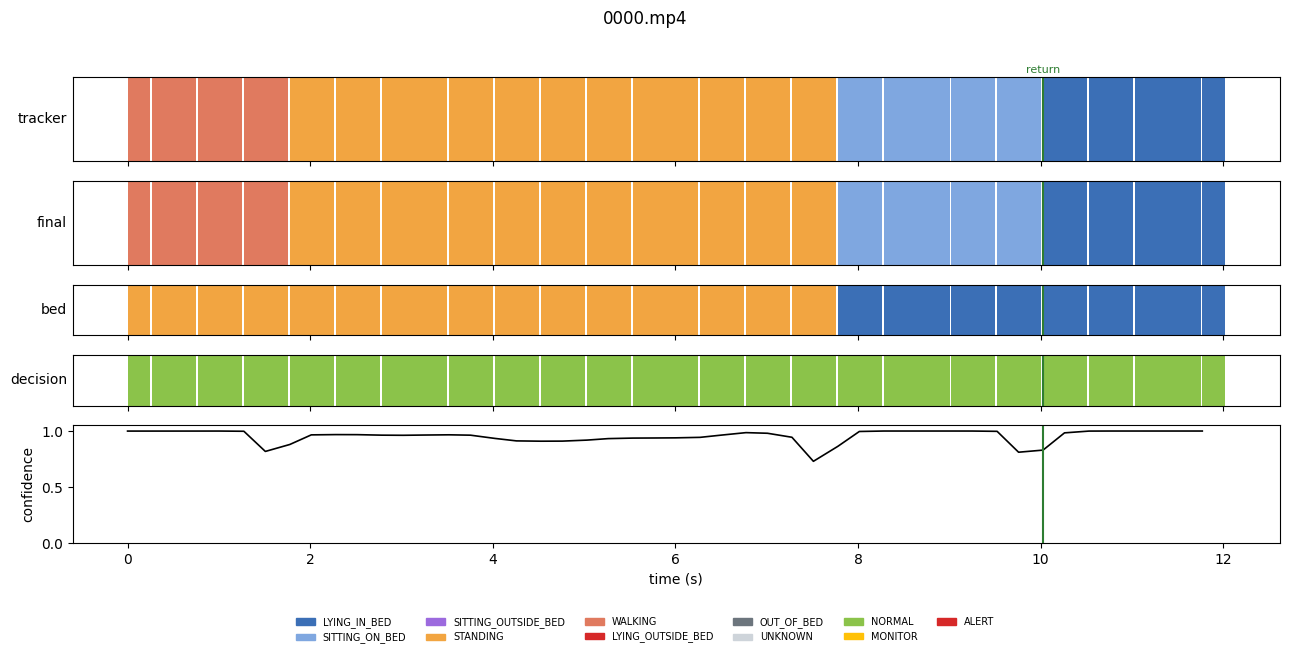

In [61]:
BED_COLORS = {"in_bed": "#3B6FB6", "out_of_bed": "#F2A541", "unknown": "#CED4DA"}
DECISION_COLORS = {"NORMAL": "#8BC34A", "MONITOR": "#FFC107", "ALERT": "#D62828"}
EVENT_STYLE = {"bed_exit": ("#D62828", "exit"), "return_to_bed": ("#2E7D32", "return"),
               "exit_attempt": ("#FB8C00", "attempt"), "bed_visit": ("#7E57C2", "visit")}

def plot_report(states, status, decisions, events, sample_fps: float, title: str = ""):
    t = states["t_sec"].to_numpy()
    dt = 1.0 / sample_fps
    fig, axes = plt.subplots(5, 1, figsize=(13, 6.5), sharex=True,
                             gridspec_kw={"height_ratios": [1, 1, 0.6, 0.6, 1.4]})
    bands = [(axes[0], states["state_tracker"] if "state_tracker" in states else states["state"], STATE_COLORS, "tracker"),
             (axes[1], states["state"], STATE_COLORS, "final"),
             (axes[2], status, BED_COLORS, "bed"),
             (axes[3], decisions["decision"], DECISION_COLORS, "decision")]
    for ax, values, colors, label in bands:
        for ti, v in zip(t, values):
            ax.axvspan(ti, ti + dt, color=colors[v], lw=0)
        ax.set_yticks([]); ax.set_ylabel(label, rotation=0, ha="right", va="center")
    axes[4].plot(t, states["confidence"], c="black", lw=1.2)
    axes[4].set_ylim(0, 1.05); axes[4].set_ylabel("confidence"); axes[4].set_xlabel("time (s)")
    for e in events:
        color, short = EVENT_STYLE.get(e["event"], ("black", e["event"]))
        x = e["confirmed_sec"] if e["confirmed_sec"] is not None else e["start_sec"]
        for ax in axes:
            ax.axvline(x, color=color, lw=1.5, ls="-" if e["status"] == "confirmed" else ":")
        axes[0].text(x, 1.05, short, color=color, transform=axes[0].get_xaxis_transform(), ha="center", fontsize=8)
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in STATE_COLORS.values()]
    handles += [plt.Rectangle((0, 0), 1, 1, color=c) for c in DECISION_COLORS.values()]
    fig.legend(handles, list(STATE_COLORS) + list(DECISION_COLORS), loc="lower center", ncol=6, fontsize=7, frameon=False)
    fig.suptitle(title)
    plt.tight_layout(rect=(0, 0.07, 1, 0.97))
    return fig

fig = plot_report(states_final_df, bed_status, decisions_df, events, cfg.sample_fps, title=Path(info.path).name)
fig.savefig(video_out / "report_plot.png", dpi=100)
plt.show()

# 09. Evaluation

You need ground truth: watch each video and write down its segments as `(start_sec, end_sec, STATE)`. The code then compares it with the final state path.

- **Activity recognition:** frame accuracy, per-state precision / recall / F1, confusion matrix, most confused state pairs.
- **Bed events:** ground-truth events come from running the **same** event state machine on the ground-truth states. So both sides use the same definition of a bed exit. A predicted event matches a true one if their start times are within `tolerance_sec`.
- **Durations:** predicted vs true time per state, and the error.
- **Failure cases:** the longest wrong periods, saved as images with both labels.

## 9.1: Ground truth
Watch the video (for example at 0.5x speed) and fill in `gt_rows`. Segments should cover the whole video with no gaps. Use the state names from `STATES`. The file is saved next to the other outputs, so you only do this once per video.

In [62]:
eval_log = logging.getLogger("bedmonitor.eval")

def save_ground_truth(rows: list, path: Path) -> pd.DataFrame:
    """Check and save ground-truth segments: [(start_sec, end_sec, STATE), ...]."""
    gt = pd.DataFrame(rows, columns=["start_sec", "end_sec", "state"]).sort_values("start_sec").reset_index(drop=True)
    bad = set(gt["state"]) - set(STATES)
    if bad:
        raise ValueError(f"Unknown states in ground truth: {bad}. Use names from STATES.")
    if (gt["end_sec"] <= gt["start_sec"]).any():
        raise ValueError("Every segment needs end_sec > start_sec")
    gaps = gt["start_sec"].iloc[1:].to_numpy() - gt["end_sec"].iloc[:-1].to_numpy()
    if (np.abs(gaps) > 0.01).any():
        eval_log.warning("Ground truth has gaps or overlaps between segments: %s", np.round(gaps, 2).tolist())
    path.parent.mkdir(parents=True, exist_ok=True)
    gt.to_csv(path, index=False)
    eval_log.info("Saved %d ground-truth segments to %s", len(gt), path)
    return gt

def load_ground_truth(path: Path) -> pd.DataFrame | None:
    if not Path(path).exists():
        return None
    return pd.read_csv(path)

GT_PATH = video_out / "ground_truth.csv"

# Fill this in after watching the video. Example format only:
# gt_rows = [(0.0, 4.5, "WALKING"), (4.5, 6.0, "STANDING"), ...]
gt_rows = []

if gt_rows:
    save_ground_truth(gt_rows, GT_PATH)
elif GT_PATH.exists():
    eval_log.info("Using existing ground truth: %s", GT_PATH)
else:
    eval_log.warning("No ground truth yet. Fill in gt_rows above to run the evaluation.")

05:32:19 | WARNING | bedmonitor.eval | No ground truth yet. Fill in gt_rows above to run the evaluation.


## 9.2: Metrics

In [63]:
def gt_labels_at(gt: pd.DataFrame, t_sec: pd.Series) -> pd.Series:
    """Ground-truth state at each frame time. 'UNLABELED' where no segment covers the time."""
    labels = pd.Series("UNLABELED", index=t_sec.index, dtype=object)
    for _, g in gt.iterrows():
        labels[(t_sec >= g["start_sec"]) & (t_sec < g["end_sec"])] = g["state"]
    return labels

def classification_metrics(y_true: pd.Series, y_pred: pd.Series):
    """Accuracy, per-state precision/recall/F1, and the confusion matrix (rows = truth)."""
    labels = [s for s in STATES if s in set(y_true) | set(y_pred)]
    conf = pd.crosstab(pd.Categorical(y_true, labels), pd.Categorical(y_pred, labels),
                       rownames=["truth"], colnames=["predicted"], dropna=False)
    rows = []
    for s in labels:
        tp = conf.loc[s, s]
        support = conf.loc[s].sum()
        pred_n = conf[s].sum()
        p = tp / pred_n if pred_n else np.nan
        r = tp / support if support else np.nan
        f1 = 2 * p * r / (p + r) if p and r and not np.isnan(p) and not np.isnan(r) else 0.0
        rows.append({"state": s, "precision": p, "recall": r, "f1": f1, "support_frames": int(support)})
    per_state = pd.DataFrame(rows)
    acc = float((y_true == y_pred).mean())
    macro_f1 = float(per_state.loc[per_state["support_frames"] > 0, "f1"].mean())
    return acc, macro_f1, per_state, conf

def top_confusions(conf: pd.DataFrame, k: int = 5) -> list:
    pairs = [(a, b, int(conf.loc[a, b])) for a in conf.index for b in conf.columns if a != b and conf.loc[a, b] > 0]
    return sorted(pairs, key=lambda x: -x[2])[:k]

def duration_table(y_true: pd.Series, y_pred: pd.Series, dt: float) -> pd.DataFrame:
    rows = []
    for s in STATES:
        g, p = float((y_true == s).sum() * dt), float((y_pred == s).sum() * dt)
        if g or p:
            rows.append({"state": s, "truth": fmt_duration(g), "predicted": fmt_duration(p),
                         "truth_sec": round(g, 1), "pred_sec": round(p, 1), "error_sec": round(p - g, 1),
                         "abs_error_sec": round(abs(p - g), 1)})
    return pd.DataFrame(rows)

def match_events(true_events: list, pred_events: list, kind: str, tol: float) -> dict:
    """Greedy one-to-one matching of event start times within `tol` seconds."""
    T = [e for e in true_events if e["event"] == kind and e["status"] == "confirmed"]
    P = [e for e in pred_events if e["event"] == kind and e["status"] == "confirmed"]
    used, matches = set(), []
    for p in sorted(P, key=lambda e: e["start_sec"]):
        best = None
        for j, g in enumerate(T):
            d = abs(p["start_sec"] - g["start_sec"])
            if j not in used and d <= tol and (best is None or d < best[1]):
                best = (j, d)
        if best:
            used.add(best[0])
            matches.append({"pred_start": p["start_sec"], "true_start": T[best[0]]["start_sec"],
                            "time_error_sec": round(p["start_sec"] - T[best[0]]["start_sec"], 2)})
    tp = len(matches)
    fp, fn = len(P) - tp, len(T) - tp
    return {"event": kind, "true": len(T), "predicted": len(P), "tp": tp, "fp": fp, "fn": fn,
            "precision": round(tp / len(P), 3) if P else None,
            "recall": round(tp / len(T), 3) if T else None, "matches": matches}

def find_failure_runs(t: pd.Series, y_true: pd.Series, y_pred: pd.Series, dt: float,
                      min_sec: float = 1.0, top_k: int = 5) -> list:
    """Longest continuous periods where prediction and truth disagree."""
    wrong = (y_true != y_pred) & (y_true != "UNLABELED")
    run_id = (wrong != wrong.shift()).cumsum()
    runs = []
    for _, idx in wrong[wrong].groupby(run_id[wrong]).groups.items():
        idx = list(idx)
        dur = len(idx) * dt
        if dur >= min_sec:
            runs.append({"start_sec": float(t[idx[0]]), "end_sec": float(t[idx[-1]] + dt), "duration_sec": dur,
                         "truth": y_true[idx].mode().iloc[0], "predicted": y_pred[idx].mode().iloc[0]})
    return sorted(runs, key=lambda r: -r["duration_sec"])[:top_k]

## 9.3: Failure-case images and plot

In [64]:
def save_failure_images(failures: list, info, cfg, scene, feats, out_dir: Path, agent_results=None) -> list:
    """Save one annotated frame (middle of each wrong period) with truth and prediction."""
    img_dir = out_dir / "failure_cases"
    img_dir.mkdir(parents=True, exist_ok=True)
    for k, fc in enumerate(failures):
        t_mid = (fc["start_sec"] + fc["end_sec"]) / 2
        old = video_log.level
        video_log.setLevel(logging.WARNING)
        try:
            frames = list(sample_frames(info, min(info.fps, 2.0), cfg.max_side, t_mid, min(info.duration_sec, t_mid + 0.6)))
        finally:
            video_log.setLevel(old)
        if not frames:
            continue
        img = draw_scene(frames[0].image, scene)
        i = (feats["t_sec"] - t_mid).abs().idxmin()
        r = feats.loc[i]
        if r["visible"]:
            cv2.rectangle(img, (int(r["x1"]), int(r["y1"])), (int(r["x2"]), int(r["y2"])), (0, 140, 255), 2)
        for j, line in enumerate([f"t={t_mid:.1f}s", f"truth: {fc['truth']}", f"pred:  {fc['predicted']}"]):
            cv2.putText(img, line, (12, 34 + 32 * j), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 5)
            cv2.putText(img, line, (12, 34 + 32 * j), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 255, 255), 2)
        path = img_dir / f"failure_{k + 1}.jpg"
        cv2.imwrite(str(path), img)
        fc["image"] = str(path)
        fc["agent_cases"] = [r2["case_id"] for r2 in agent_results or []
                             if r2["t0"] < fc["end_sec"] and r2["t1"] > fc["start_sec"]]
    return failures

def plot_truth_vs_pred(t, y_true, y_pred, sample_fps: float, title: str = ""):
    dt = 1.0 / sample_fps
    colors = {**STATE_COLORS, "UNLABELED": "#FFFFFF"}
    fig, axes = plt.subplots(3, 1, figsize=(13, 3.2), sharex=True)
    for ax, values, label in [(axes[0], y_true, "truth"), (axes[1], y_pred, "predicted")]:
        for ti, v in zip(t, values):
            ax.axvspan(ti, ti + dt, color=colors[v], lw=0)
        ax.set_yticks([]); ax.set_ylabel(label, rotation=0, ha="right", va="center")
    wrong = (y_true != y_pred) & (y_true != "UNLABELED")
    for ti in t[wrong]:
        axes[2].axvspan(ti, ti + dt, color="#D62828", lw=0)
    axes[2].set_yticks([]); axes[2].set_ylabel("wrong", rotation=0, ha="right", va="center")
    axes[2].set_xlabel("time (s)")
    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in STATE_COLORS.values()]
    fig.legend(handles, list(STATE_COLORS), loc="lower center", ncol=4, fontsize=7, frameon=False)
    fig.suptitle(title)
    plt.tight_layout(rect=(0, 0.12, 1, 0.95))
    return fig

## 9.4: Evaluate this video

In [65]:
def evaluate_video(states, events, gt, feats, scene, info, cfg, ecfg, out_dir: Path,
                   agent_results=None, tolerance_sec: float = 5.0) -> dict:
    dt = 1.0 / cfg.sample_fps
    t = states["t_sec"]
    y_true = gt_labels_at(gt, t)
    labeled = y_true != "UNLABELED"
    if not labeled.any():
        eval_log.warning("Ground truth covers no frames")
        return {}
    y_pred = states["state"].astype(object)
    unlabeled_share = 1 - labeled.mean()
    if unlabeled_share > 0:
        eval_log.warning("%.0f%% of frames have no ground truth and are skipped", 100 * unlabeled_share)

    # Activity recognition (also for the tracker alone, to show what the agent changed)
    acc, macro_f1, per_state, conf = classification_metrics(y_true[labeled], y_pred[labeled])
    tracker_acc = None
    if "state_tracker" in states:
        tracker_acc = float((y_true[labeled] == states.loc[labeled, "state_tracker"]).mean())

    # Bed events: same state machine on the ground truth
    gt_states = pd.DataFrame({"t_sec": t[labeled].to_numpy(), "state": y_true[labeled].to_numpy(), "confidence": 1.0})
    gt_events = detect_bed_events(gt_states, bed_status_track(gt_states), ecfg)
    exits = match_events(gt_events, events, "bed_exit", tolerance_sec)
    returns = match_events(gt_events, events, "return_to_bed", tolerance_sec)

    durations = duration_table(y_true[labeled], y_pred[labeled], dt)
    failures = find_failure_runs(t, y_true, y_pred, dt)
    failures = save_failure_images(failures, info, cfg, scene, feats, out_dir, agent_results)

    result = {
        "video": Path(info.path).name,
        "frames_evaluated": int(labeled.sum()),
        "accuracy": round(acc, 3),
        "accuracy_tracker_only": round(tracker_acc, 3) if tracker_acc is not None else None,
        "macro_f1": round(macro_f1, 3),
        "per_state": per_state.round(3).to_dict(orient="records"),
        "confusion": conf.to_dict(),
        "top_confusions": top_confusions(conf),
        "bed_exit": exits,
        "return_to_bed": returns,
        "false_bed_exits": exits["fp"],
        "durations": durations.to_dict(orient="records"),
        "mean_abs_duration_error_sec": round(float(durations["abs_error_sec"].mean()), 1) if len(durations) else None,
        "failure_cases": failures,
    }

    eval_log.info("Accuracy %.1f%% (tracker only: %s), macro F1 %.2f, %d frames",
                  100 * acc, f"{100 * tracker_acc:.1f}%" if tracker_acc is not None else "-", macro_f1, labeled.sum())
    eval_log.info("Bed exits: %d true, %d predicted, precision %s, recall %s, false exits %d",
                  exits["true"], exits["predicted"], exits["precision"], exits["recall"], exits["fp"])
    eval_log.info("Returns:   %d true, %d predicted, precision %s, recall %s",
                  returns["true"], returns["predicted"], returns["precision"], returns["recall"])
    for a, b, n in result["top_confusions"]:
        eval_log.info("  Confused %s -> %s: %d frames (%.1f s)", a, b, n, n * dt)
    eval_log.info("Failure cases saved: %d", len(failures))

    out_dir.mkdir(parents=True, exist_ok=True)
    (out_dir / "eval.json").write_text(json.dumps(result, indent=2, default=str))
    fig = plot_truth_vs_pred(t, y_true, y_pred, cfg.sample_fps, title=f"{Path(info.path).name}: truth vs predicted")
    fig.savefig(out_dir / "eval_timeline.png", dpi=100)
    eval_log.info("Saved eval.json, eval_timeline.png and failure images to %s", out_dir)
    return result

gt = load_ground_truth(GT_PATH)
if gt is None:
    eval_log.warning("Skipping evaluation: no ground truth at %s", GT_PATH)
else:
    eval_result = evaluate_video(states_final_df, events, gt, features_df, scene, info, cfg, ecfg, video_out,
                                 agent_results=agent_results)
    display(pd.DataFrame(eval_result["per_state"]))
    display(pd.DataFrame(eval_result["durations"])[["state", "truth", "predicted", "error_sec"]])
    print(json.dumps({k: eval_result[k] for k in ["bed_exit", "return_to_bed"]}, indent=2))
    plt.show()

05:32:21 | WARNING | bedmonitor.eval | Skipping evaluation: no ground truth at /kaggle/working/outputs/0000/ground_truth.csv


## 9.5: Combine results from all videos
Run this after Section 10 has processed several videos with ground truth.

In [66]:
def combine_evaluations(output_dir: Path) -> pd.DataFrame:
    """One row per evaluated video, plus totals for bed events."""
    rows = []
    for path in sorted(Path(output_dir).glob("*/eval.json")):
        r = json.loads(path.read_text())
        rows.append({
            "video": r["video"], "frames": r["frames_evaluated"], "accuracy": r["accuracy"],
            "accuracy_tracker_only": r["accuracy_tracker_only"], "macro_f1": r["macro_f1"],
            "exit_tp": r["bed_exit"]["tp"], "exit_fp": r["bed_exit"]["fp"], "exit_fn": r["bed_exit"]["fn"],
            "return_tp": r["return_to_bed"]["tp"], "return_fp": r["return_to_bed"]["fp"],
            "return_fn": r["return_to_bed"]["fn"], "mean_abs_duration_error_sec": r["mean_abs_duration_error_sec"],
        })
    df = pd.DataFrame(rows)
    if df.empty:
        eval_log.warning("No eval.json files found under %s", output_dir)
        return df
    tp, fp, fn = df["exit_tp"].sum(), df["exit_fp"].sum(), df["exit_fn"].sum()
    w_acc = (df["accuracy"] * df["frames"]).sum() / df["frames"].sum()
    eval_log.info("All videos: %d videos, frame accuracy %.1f%%", len(df), 100 * w_acc)
    eval_log.info("All videos: bed-exit precision %s, recall %s, false exits %d",
                  round(tp / (tp + fp), 3) if tp + fp else None, round(tp / (tp + fn), 3) if tp + fn else None, fp)
    return df

all_eval_df = combine_evaluations(Path(cfg.output_dir))
display(all_eval_df)

05:32:22 | WARNING | bedmonitor.eval | No eval.json files found under /kaggle/working/outputs


""


# 10. Run All Layers on More Videos

`run_pipeline` chains every layer for one video and writes all outputs to `outputs/<video name>/`. Use it for your test videos.

- If a video has a `ground_truth.csv` in its output folder, it is also evaluated.
- Scene settings in `scfg` (for example a manual `bed_polygon`) apply to every video. Reset them if your videos use different cameras.
- The VLM loaded in 6.9 is reused.

## 10.1: Pipeline function

In [67]:
pipe_log = logging.getLogger("bedmonitor.pipeline")

def run_pipeline(video_path: str, force_perception: bool = False, gt_rows: list | None = None,
                 ecfg_run: EventConfig | None = None) -> dict:
    """Video -> scene -> perception -> features -> states -> agent -> events -> report (-> evaluation)."""
    ecfg_run = ecfg_run or ecfg
    t_start = time.perf_counter()
    v_info = probe_video(video_path)
    out = Path(cfg.output_dir) / Path(video_path).stem
    pipe_log.info("=== %s -> %s ===", Path(video_path).name, out)

    v_scene = build_scene(v_info, cfg, scfg, YOLO(scfg.detect_model), out)
    v_scene.save(out / "scene.json")
    cv2.imwrite(str(out / "scene_overview.jpg"), draw_scene(cv2.imread(str(out / "reference_color.jpg")), v_scene))

    v_frames, v_persons = run_perception(v_info, cfg, pcfg, v_scene, out, force=force_perception)
    v_feat, v_tracks = run_features(v_persons, v_frames, v_scene, fcfg, cfg, out)
    v_states, v_segs = run_state_tracker(v_feat, v_scene, scfg_states, cfg.sample_fps, out)
    v_final, v_segs_final, v_agent = run_agent(v_states, v_feat, v_segs, v_tracks, v_scene, v_info, cfg, acfg,
                                               scfg_states, out, vlm=vlm_client)
    v_status, v_events, v_dec, v_alerts = run_events(v_final, v_feat, ecfg_run, cfg.sample_fps, out, v_agent)
    v_report = build_report(v_final, v_segs_final, v_status, v_events, v_alerts, v_dec, v_agent, v_info, cfg)
    save_report(v_report, out)
    plot_report(v_final, v_status, v_dec, v_events, cfg.sample_fps, Path(video_path).name).savefig(out / "report_plot.png", dpi=100)
    plt.close("all")

    if gt_rows:
        save_ground_truth(gt_rows, out / "ground_truth.csv")
    v_gt = load_ground_truth(out / "ground_truth.csv")
    if v_gt is not None:
        evaluate_video(v_final, v_events, v_gt, v_feat, v_scene, v_info, cfg, ecfg_run, out, agent_results=v_agent)
        plt.close("all")

    pipe_log.info("=== %s done in %.0f s: %s ===", Path(video_path).name, time.perf_counter() - t_start,
                  {k: v_report["summary"][k] for k in ["bed_exit_count", "bed_return_count", "worst_decision"]})
    return v_report["summary"]

## 10.2: Run a list of videos

In [68]:
# Add your test videos here. Optional: ground truth per video as {video_path: gt_rows}.
VIDEO_PATHS = [
    # "/kaggle/input/datasets/dinethm/bed-monitor-sample/0001.mp4",
]
GT_BY_VIDEO = {}

all_summaries = {}
for p in VIDEO_PATHS:
    try:
        all_summaries[Path(p).stem] = run_pipeline(p, gt_rows=GT_BY_VIDEO.get(p))
    except Exception as e:      # one bad video should not stop the batch
        pipe_log.error("Failed on %s: %s", p, e)

if all_summaries:
    display(pd.DataFrame(all_summaries).T)
    all_eval_df = combine_evaluations(Path(cfg.output_dir))
    display(all_eval_df)